# StarDist Model Training

Notebook này huấn luyện model StarDist để phát hiện và phân đoạn bọt khí.

## Các bước chính:
1. **Import thư viện**
2. **Cấu hình tham số**
3. **Load dữ liệu**
4. **Tiền xử lý dữ liệu**
5. **Chia Train/Validation**
6. **Định nghĩa Data Augmentation**
7. **Cấu hình và tạo Model**
8. **Huấn luyện**
9. **Tối ưu ngưỡng**
10. **Đánh giá kết quả**

In [1]:
import configparser
import sys

# 1. Gán SafeConfigParser bằng ConfigParser (vì chúng giống hệt nhau về chức năng)
configparser.SafeConfigParser = configparser.ConfigParser

# 2. Đưa nó vào hệ thống module của Python để các thư viện khác tìm thấy
sys.modules['configparser'].SafeConfigParser = configparser.ConfigParser

print("Đã vá lỗi SafeConfigParser thành công!")

Đã vá lỗi SafeConfigParser thành công!


In [2]:
# Chạy lệnh này ở ô tiếp theo
!pip install gputools

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 8.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 732.6/732.6 kB 25.6 MB/s eta 0:00:00
  Created wheel for gputools: filename=gputools-0.2.16-py3-none-any.whl size=139959 sha256=524563bc117850d6aadad9a4e48cec8934fe008c47ca43c0a23a80218cb6191d
  Stored in directory: /root/.cache/pip/wheels/dc/81/06/5f0cf589f972a27ba80e7968aa0e889da6bf72da331cc7bcb0
  Created wheel for reikna: filename=reikna-0.9.0-py3-none-any.whl size=122539 sha256=81b45820fc03f419d93792dd81c9cb1476fb06cec311875558a563be39a1d65c
  Stored in directory: /root/.cache/pip/wheels/64/2d/b6/4bb0fdffbabd13961c5a8e47ee04393c23e4f937d49adad071
Successfully built gputools reikna


In [3]:
import gputools

# Kiểm tra thử xem thư viện đã nhận chưa
print(gputools.__version__)

/usr/local/lib/python3.12/dist-packages/pyopencl/__init__.py:570: CompilerWarning: Non-empty compiler output encountered. Set the environment variable PYOPENCL_COMPILER_OUTPUT=1 to see more.
  lambda: self._prg.build(options_bytes, devices),


If you want to compute separable approximations, please install it with
pip install scikit-tensor-py3
0.2.16


---
## Bước 1: Import thư viện

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import os
import json
from glob import glob
from tqdm import tqdm
from tifffile import imread
from PIL import Image

# StarDist imports
from stardist import fill_label_holes, gputools_available, random_label_cmap
from stardist.models import StarDist2D, Config2D
from stardist.matching import matching_dataset

# CSBDeep imports
from csbdeep.utils import normalize

# Colormap cho visualization
lbl_cmap = random_label_cmap()

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard, CSVLogger
import pandas as pd

2025-12-26 08:50:24.298284: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766739024.484908      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766739024.537199      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766739024.986180      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766739024.986221      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766739024.986224      55 computation_placer.cc:177] computation placer alr

---
## Bước 2: Cấu hình tham số

In [11]:
# Đường dẫn thư mục
RAW_DATA_FOLDER = '/kaggle/input/datav3/data/'
MODEL_FOLDER = '/kaggle/working/models/'

# Tên dataset
DATA_NAME = 'datav3'

# Tham số training
EPOCHS = 600           # Số epoch huấn luyện
RAYS = 64             # Số lượng tia phát ra từ tâm
VAL_RATIO = 0.2      # Tỷ lệ validation (20%)

# Đường dẫn pretrained model (nếu có)
#PRETRAINED_CONFIG = '../models/SDmodel/stardist/config.json'
#PRETRAINED_WEIGHTS = '../models/SDmodel/stardist/weights_last.h5'

# Tên model output
MODEL_NAME = f'200_flat_origin_val_loss_true'
MODEL_NAME_1 = f'200_flat_origin_val_loss_false'

MODEL_NAME_2 = f'200_flat_origin_dist_dist_iou_metric_true'
MODEL_NAME_3 = f'200_flat_origin_dist_dist_iou_metric_false'

print(f"Epochs: {EPOCHS}")
print(f"Rays: {RAYS}")

Epochs: 600
Rays: 64


---
## Bước 3: Load dữ liệu

In [12]:
# Đường dẫn tới thư mục chứa ảnh và mask
image_folder = os.path.join(RAW_DATA_FOLDER, 'img')
mask_folder = os.path.join(RAW_DATA_FOLDER,'mask')

print(f"Image folder: {image_folder}")
print(f"Mask folder: {mask_folder}")

Image folder: /kaggle/input/datav3/data/img
Mask folder: /kaggle/input/datav3/data/mask


In [13]:
# Đọc các đường dẫn tới file ảnh và mask
image_files = sorted(glob(os.path.join(image_folder, '*')))
mask_files = sorted(glob(os.path.join(mask_folder, '*.tif')))

# Kiểm tra số lượng file
print(f"Số ảnh: {len(image_files)}")
print(f"Số mask: {len(mask_files)}")

assert len(image_files) == len(mask_files), "Số lượng ảnh và mask không khớp!"

Số ảnh: 184
Số mask: 184


In [14]:
# Đọc dữ liệu vào memory
def load_and_convert_to_gray(folder_path):
    data_list = []
    # Lấy danh sách file và sort để đảm bảo thứ tự
    files = sorted(os.listdir(folder_path))
    
    print(f"Loading from: {folder_path}")
    
    for filename in tqdm(files):
        # Chấp nhận các đuôi ảnh phổ biến
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp')):
            file_path = os.path.join(folder_path, filename)
            try:
                with Image.open(file_path) as img:
                    # Logic cốt lõi: Convert sang Grayscale "L"
                    img_gray = img.convert("L")
                    
                    # Chuyển từ PIL Image sang Numpy array để StarDist dùng được
                    img_array = np.array(img_gray)
                    
                    data_list.append(img_array)
            except Exception as e:
                print(f"Error loading {filename}: {e}")
                
    return data_list

# --- SỬ DỤNG ---
X = load_and_convert_to_gray(image_folder)
Y = list(map(imread, mask_files))

print(f"Done! X size: {len(X)}, Y size: {len(Y)}")
print(f"Shape ảnh đầu tiên: {X[0].shape}")
print(f"Shape mask đầu tiên: {Y[0].shape}")

# Kiểm tra kích thước ảnh và mask phải khớp nhau
for i, (x, y) in enumerate(zip(X, Y)):
    assert x.shape == y.shape, f"Ảnh {i} và mask không cùng kích thước: {x.shape} vs {y.shape}"

print("✓ Tất cả ảnh và mask có cùng kích thước")

all_min = min([np.min(x) for x in X])
all_max = max([np.max(x) for x in X])
print(f"X - Min: {all_min}, Max: {all_max}")
all_min = min([np.min(x) for y in Y])
all_max = max([np.max(x) for y in Y])
print(f"Y - Min: {all_min}, Max: {all_max}")

Loading from: /kaggle/input/datav3/data/img


100%|██████████| 184/184 [00:02<00:00, 70.25it/s]


Done! X size: 184, Y size: 184
Shape ảnh đầu tiên: (512, 1024)
Shape mask đầu tiên: (512, 1024)
✓ Tất cả ảnh và mask có cùng kích thước
X - Min: 0, Max: 255
Y - Min: 0, Max: 249


---
## Bước 4: Tiền xử lý dữ liệu

In [15]:
# Trục cần được chuẩn hóa (theo chiều không gian: trục 0 và 1)
axis_norm = (0, 1)

# Chuẩn hóa dữ liệu đầu vào (X)
# Scale pixel theo percentiles 1% và 99.8%
# Giúp loại bỏ ảnh hưởng của outliers và chuẩn hóa độ sáng
X = [normalize(x, 1, 99.8, axis=axis_norm) for x in tqdm(X, desc="Normalizing")]

print("✓ Đã chuẩn hóa ảnh")
# Hoặc kiểm tra Min/Max của toàn bộ tập dữ liệu (cẩn thận nếu data lớn)
all_min = min([np.min(x) for x in X])
all_max = max([np.max(x) for x in X])
print(f"Toàn bộ dataset - Min: {all_min:.4f}, Max: {all_max:.4f}")


Normalizing: 100%|██████████| 184/184 [00:01<00:00, 162.35it/s]


✓ Đã chuẩn hóa ảnh
Toàn bộ dataset - Min: -0.1117, Max: 1.4817


Text(0.5, 1.0, 'mask')

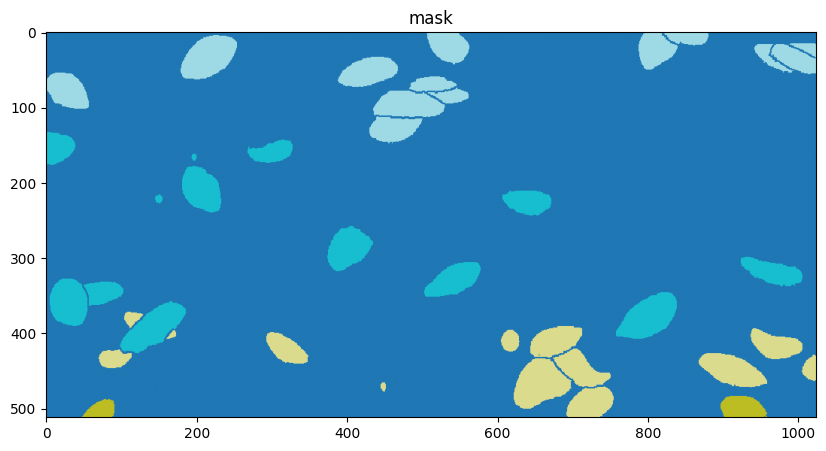

In [16]:

fig, (ax1) = plt.subplots(1,  figsize=(10, 5))
ax1.imshow(Y[0], cmap='tab20')
ax1.set_title("mask")

In [17]:
# Điền lỗ hổng (fill holes) trong mask
Y = [fill_label_holes(y) for y in tqdm(Y, desc="Filling label holes")]

print("✓ Đã điền lỗ trong mask")

Filling label holes: 100%|██████████| 184/184 [00:01<00:00, 99.16it/s] 

✓ Đã điền lỗ trong mask


IoU (Filled vs Relabeled): 0.9785
✓ OK: Objects có hình dạng gần với star-convex.


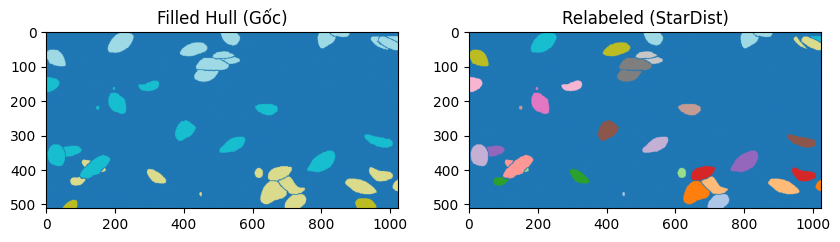

In [18]:
from stardist.geometry import relabel_image_stardist

# Chọn thử mask đầu tiên
y_filled = Y[0]

# Tạo mask tái tạo (relabel) dùng số RAYS đã config
# Hàm này sẽ vẽ lại object dưới dạng star-convex polygon
y_relabeled = relabel_image_stardist(y_filled, n_rays=RAYS)

# Hàm tính IoU giữa 2 mask
def compute_iou(y_true, y_pred):
    # Chỉ tính trên vùng có object (bỏ qua background 0)
    mask_true = y_true > 0
    mask_pred = y_pred > 0
    
    intersection = np.logical_and(mask_true, mask_pred).sum()
    union = np.logical_or(mask_true, mask_pred).sum()
    
    return intersection / union if union > 0 else 0

iou = compute_iou(y_filled, y_relabeled)
print(f"IoU (Filled vs Relabeled): {iou:.4f}")

if iou < 0.9:
    print("CẢNH BÁO: IoU thấp, có thể objects không star-convex!")
else:
    print("✓ OK: Objects có hình dạng gần với star-convex.")

# Hiển thị so sánh
# Lưu ý: Cần định nghĩa hàm plot_img_label trước hoặc di chuyển cell này xuống dưới cùng sau khi định nghĩa hàm đó
# Hoặc copy hàm plot_img_label lên đây để chạy độc lập
def plot_img_label_local(lbl1, lbl2, t1, t2):
    import matplotlib.pyplot as plt
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    ax1.imshow(lbl1, cmap='tab20')
    ax1.set_title(t1)
    ax2.imshow(lbl2, cmap='tab20')
    ax2.set_title(t2)
    plt.show()

plot_img_label_local(y_filled, y_relabeled, "Filled Hull (Gốc)", "Relabeled (StarDist)")

---
## Bước 5: Chia Train/Validation

In [19]:
# Seed ngẫu nhiên để reproducible
rng = np.random.RandomState(42)

# Hoán vị chỉ số của toàn bộ dữ liệu
ind = rng.permutation(len(X))

# Tính số lượng validation (tỷ lệ VAL_RATIO)
n_val = max(1, int(round(VAL_RATIO * len(ind))))

# Chia chỉ số train và validation
ind_train, ind_val = ind[:-n_val], ind[-n_val:]

print(f"Train indices: {len(ind_train)}")
print(f"Val indices: {len(ind_val)}")

Train indices: 147
Val indices: 37


In [20]:
# Lấy dữ liệu train và validation theo chỉ số
X_trn = [X[i] for i in ind_train]
Y_trn = [Y[i] for i in ind_train]

X_val = [X[i] for i in ind_val]
Y_val = [Y[i] for i in ind_val]

print(f"\nTổng quan dữ liệu:")
print(f"  - Tổng số ảnh: {len(X)}")
print(f"  - Training: {len(X_trn)} ảnh")
print(f"  - Validation: {len(X_val)} ảnh")


Tổng quan dữ liệu:
  - Tổng số ảnh: 184
  - Training: 147 ảnh
  - Validation: 37 ảnh


---
## Bước 6: Định nghĩa Data Augmentation

Data augmentation giúp tăng đa dạng dữ liệu training, giúp model học tốt hơn và tránh overfitting.

In [21]:
def random_fliprot(img, mask):
    """
    Flip và xoay ngẫu nhiên ảnh và mask.
    """
    assert img.ndim >= mask.ndim
    axes = tuple(range(mask.ndim))
    perm = tuple(np.random.permutation(axes))
    img = img.transpose(perm + tuple(range(mask.ndim, img.ndim)))
    mask = mask.transpose(perm)
    for ax in axes:
        if np.random.rand() > 0.5:
            img = np.flip(img, axis=ax)
            mask = np.flip(mask, axis=ax)
    return img, mask

In [22]:
def random_intensity_change(img):
    """
    Thay đổi cường độ ảnh ngẫu nhiên (brightness/contrast).
    """
    img = img * np.random.uniform(0.6, 2) + np.random.uniform(-0.2, 0.2)
    return img

In [23]:
def augmenter(x, y):
    """
    Augmentation của một cặp input/label image.
    
    Args:
        x: ảnh đầu vào
        y: mask tương ứng
    
    Returns:
        x, y: ảnh và mask đã được augment
    """
    # 1. Flip và xoay ngẫu nhiên
    x, y = random_fliprot(x, y)
    
    # 2. Thay đổi cường độ ảnh ngẫu nhiên
    x = random_intensity_change(x)
    
    # 3. Thêm nhiễu Gaussian để tăng độ phong phú
    sig = 0.02 * np.random.uniform(0, 1)  # sigma từ 0 đến 0.02
    x = x + sig * np.random.normal(0, 1, x.shape)
    
    return x, y

print("✓ Định nghĩa augmenter thành công")

✓ Định nghĩa augmenter thành công


---
## Bước 7: Cấu hình và tạo Model

In [24]:
def printCfg(cfg):
    print(f'- configration - {cfg}')
    vars(cfg)  # Hiển thị tất cả các thuộc tính cấu hình
    
    print("Config:")
    print(f"  - n_rays: {cfg.n_rays}")
    print(f"  - grid: {cfg.grid}")
    print(f"  - train_patch_size: {cfg.train_patch_size}")

In [25]:
def intModel (cfg, modelName):
    model = StarDist2D(
        config=cfg,
        name=modelName,
        basedir= MODEL_FOLDER
    )
    
    print(f"✓ Tạo model '{MODEL_NAME}' thành công")
    return model


In [26]:
# Load weights từ pretrained model
#model.keras_model.load_weights(PRETRAINED_WEIGHTS)

#print("✓ Load pretrained weights thành công")

---
## Bước 8: Huấn luyện

In [27]:
def trainModel(model, monitor_metric, monitor_mode,X_val,Y_val ):
    # Chuẩn bị model cho training để có thể thêm callbacks tùy chỉnh
    model.prepare_for_training()
    
    # Khởi tạo EarlyStopping callback
    early_stopping = EarlyStopping(
        monitor=monitor_metric, 
        mode=monitor_mode,
        min_delta=0.001, 
        patience=50, 
        restore_best_weights=True,
        verbose=1
    )
    print(f"✓ Đã cấu hình EarlyStopping: Monitor '{monitor_metric}' (Mode: {monitor_mode})")
    
    # 2. Logging: Lưu log history vào CSV
    csv_logger = CSVLogger(os.path.join(LOG_DIR, 'training_log.csv'), append=True)
    
    # Thêm vào danh sách callbacks của model
    model.callbacks = [cb for cb in model.callbacks if not isinstance(cb, (EarlyStopping, CSVLogger))]
    model.callbacks.append(early_stopping)
    model.callbacks.append(csv_logger)
    
    print("✓ Đã cập nhật Callbacks cho Model")
    
    # Huấn luyện model
    history = model.train(
        X_trn, Y_trn,
        epochs=EPOCHS,
        validation_data=(X_val, Y_val),
        augmenter=augmenter
    )

    print("\n✓ Huấn luyện hoàn tất!")
    return model, history


In [28]:
def plot_history(history, model_name, log_dir):
    if history is None:
        print("History is None, cannot plot.")
        return

    hist_df = pd.DataFrame(history.history)
    
    # 1. Thiết lập kích thước hợp lý cho trang A4 báo cáo
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 16))
    
    # 2. Cấu hình Font chữ to để khi thu nhỏ vào báo cáo vẫn đọc được
    TITLE_SIZE = 18
    LABEL_SIZE = 14
    LEGEND_SIZE = 12
    
    epochs_range = range(1, len(hist_df) + 1)

    # --- Ô 1: TỔNG LOSS (Train vs Val) ---
    ax1.plot(epochs_range, hist_df['loss'], label='Train Loss', color='blue')
    if 'val_loss' in hist_df.columns:
        ax1.plot(epochs_range, hist_df['val_loss'], label='Val Loss', color='red')
    ax1.set_title(f'{model_name} - Total Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # --- Ô 2: THÀNH PHẦN LOSS (Dist vs Prob) ---
    # Đây là các loss đặc thù của StarDist
    if 'dist_loss' in hist_df.columns:
        ax2.plot(epochs_range, hist_df['dist_loss'], label='Train Dist Loss', linestyle='--')
        ax2.plot(epochs_range, hist_df['val_dist_loss'], label='Val Dist Loss')
        ax2.plot(epochs_range, hist_df['prob_loss'], label='Train Prob Loss', linestyle='--')
        ax2.plot(epochs_range, hist_df['val_prob_loss'], label='Val Prob Loss')
        ax2.set_title('Component Losses')
        ax2.set_xlabel('Epoch')
        ax2.legend()
        ax2.grid(True)

    # --- Ô 3: ĐỘ CHÍNH XÁC (IoU Metric) ---
    # Vẽ chỉ số IoU (Intersection over Union) để biết mô hình khớp vật thể tốt thế nào
    iou_col = 'dist_dist_iou_metric'
    val_iou_col = 'val_dist_dist_iou_metric'
    
    if iou_col in hist_df.columns:
        ax3.plot(epochs_range, hist_df[iou_col], label='Train IoU', color='green')
        if val_iou_col in hist_df.columns:
            ax3.plot(epochs_range, hist_df[val_iou_col], label='Val IoU', color='orange')
        ax3.set_title('Accuracy Metric (IoU)')
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('Score')
        ax3.legend()
        ax3.grid(True)

    # Lưu và hiển thị
    plt.tight_layout() # Tự động căn chỉnh để các chữ không đè lên nhau
    plot_path = os.path.join(log_dir, 'training_history.png')
    plt.savefig(plot_path)

    # Lưu biểu đồ
    out_dir = os.path.join(MODEL_FOLDER, model_name, "metrics")
    os.makedirs(out_dir, exist_ok=True)
    plt.savefig(os.path.join(out_dir, "training_history.png"))
    plt.show()
    
    # Lưu file CSV
    hist_df.to_csv(os.path.join(log_dir, 'history_final.csv'), index=False)
    print(f"Đã lưu biểu đồ tại: {plot_path}")

---
## Bước 9: Tối ưu ngưỡng

StarDist sử dụng 2 ngưỡng quan trọng:
- **prob_thresh**: Ngưỡng xác suất để lọc pixel nào là "center candidate"
- **nms_thresh**: Ngưỡng NMS để loại bỏ các detections trùng lặp

In [29]:
# Tối ưu ngưỡng dựa trên validation set
# Hàm này sẽ thử nhiều cặp (prob_thresh, nms_thresh) 
# và chọn cặp cho F1-score cao nhất
#model.optimize_thresholds(X_val, Y_val)



---
## Bước 10: Đánh giá kết quả

In [30]:
# Hàm visualization
def plot_img_label(img, lbl, img_title="image", lbl_title="label"):
    """
    Hiển thị ảnh và label cạnh nhau.
    """
    fig, (ai, al) = plt.subplots(1, 2, figsize=(12, 5), 
                                  gridspec_kw=dict(width_ratios=(1.25, 1)))
    
    im = ai.imshow(img, cmap='gray', clim=(0, 1))
    ai.set_title(img_title)
    fig.colorbar(im, ax=ai)
    
    al.imshow(lbl, cmap=lbl_cmap)
    al.set_title(lbl_title)
    
    plt.tight_layout()
    plt.show()

In [31]:
def valPrediction(model):
    # Predict trên validation set
    Y_val_pred = []
    for x in tqdm(X_val, desc="Predicting"):
        lbl, _ = model.predict_instances(
            x,
            n_tiles=model._guess_n_tiles(x),
            show_tile_progress=False
        )
        Y_val_pred.append(lbl)
    
    print(f"\n✓ Đã predict {len(Y_val_pred)} ảnh validation")
    return Y_val_pred

In [32]:
 def plot_GT_Pred(Y_val_pred):
     # Hiển thị so sánh Ground Truth vs Prediction
    print("Ground Truth:")
    plot_img_label(X_val[0], Y_val[0], lbl_title="Label GT")
    
    print("\nPrediction:")
    plot_img_label(X_val[0], Y_val_pred[0], lbl_title="Label Pred")

In [33]:
def matching_IoUs(Y_val, Y_val_pred):
    # Tính matching statistics với các IoU thresholds khác nhau
    taus = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
    
    stats = []
    for t in tqdm(taus, desc="Computing matching stats"):
        s = matching_dataset(Y_val, Y_val_pred, thresh=t, show_progress=False)
        stats.append(s)
    
    # In kết quả chi tiết
    print("\n" + "="*60)
    print("KẾT QUẢ ĐÁNH GIÁ")
    print("="*60)
    
    for i, tau in enumerate(taus):
        s = stats[i]
        print(f"\nIoU threshold τ = {tau}:")
        print(f"  - Precision: {s.precision:.4f}")
        print(f"  - Recall:    {s.recall:.4f}")
        print(f"  - F1:        {s.f1:.4f}")
        print(f"  - TP: {s.tp}, FP: {s.fp}, FN: {s.fn}")
    return stats

In [34]:
def plot_results_details(stats,model_name):
    # Vẽ biểu đồ metrics
    taus = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot 1: Các metrics chính
    metrics = ('precision', 'recall', 'accuracy', 'f1',
               'mean_true_score', 'mean_matched_score', 'panoptic_quality')
    for m in metrics:
        ax1.plot(taus, [s._asdict()[m] for s in stats], '.-', lw=2, label=m)
    ax1.set_xlabel(r'IoU threshold $\tau$')
    ax1.set_ylabel('Metric value')
    ax1.set_title('Metrics vs IoU Threshold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Plot 2: TP, FP, FN
    for m in ('fp', 'tp', 'fn'):
        ax2.plot(taus, [s._asdict()[m] for s in stats], '.-', lw=2, label=m)
    ax2.set_xlabel(r'IoU threshold $\tau$')
    ax2.set_ylabel('Number #')
    ax2.set_title('TP/FP/FN vs IoU Threshold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    
    # Lưu biểu đồ
    out_dir = os.path.join(MODEL_FOLDER, model_name, "metrics")
    os.makedirs(out_dir, exist_ok=True)
    plt.savefig(os.path.join(out_dir, "matching_tau_curve.png"))
    plt.show()
    
    print(f"\n✓ Đã lưu biểu đồ vào {out_dir}")

# I. val_loss_false 

In [35]:
# Cấu hình mô hình StarDist
cfg = Config2D(
    n_rays=RAYS,
    use_gpu = True,
    n_channel_in = 1,
    unet_n_depth = 3,
    train_patch_size = [256,256],
    unet_pool = [2,2],
    grid = [4,4],
    train_shape_completion = True,
    train_reduce_lr= {"factor": 0.5, "patience": 20, "min_delta": 0.0001}
)

printCfg(cfg)

- configration - Config2D(n_dim=2, axes='YXC', n_channel_in=1, n_channel_out=65, train_checkpoint='weights_best.h5', train_checkpoint_last='weights_last.h5', train_checkpoint_epoch='weights_now.h5', n_rays=64, grid=(4, 4), backbone='unet', n_classes=None, unet_n_depth=3, unet_kernel_size=(3, 3), unet_n_filter_base=32, unet_n_conv_per_depth=2, unet_pool=[2, 2], unet_activation='relu', unet_last_activation='relu', unet_batch_norm=False, unet_dropout=0.0, unet_expansion=2, unet_prefix='', net_conv_after_unet=128, net_input_shape=(None, None, 1), net_mask_shape=(None, None, 1), train_shape_completion=True, train_completion_crop=32, train_patch_size=[256, 256], train_background_reg=0.0001, train_foreground_only=0.9, train_sample_cache=True, train_dist_loss='mae', train_loss_weights=(1, 0.2), train_class_weights=(1, 1), train_epochs=400, train_steps_per_epoch=100, train_learning_rate=0.0003, train_batch_size=4, train_n_val_patches=None, train_tensorboard=True, train_reduce_lr={'factor': 0.5,

In [36]:
# model name
model_name = MODEL_NAME

# Logging Directory
LOG_DIR = os.path.join(MODEL_FOLDER, model_name, 'logs')
if not os.path.exists(LOG_DIR):
    os.makedirs(LOG_DIR)


In [37]:
model = intModel (cfg = cfg, modelName = model_name)


base_model.py (203): output path for model already exists, files may be overwritten: /kaggle/working/models/200_flat_origin_val_loss_true
I0000 00:00:1766739046.613115      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13844 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1766739046.613767      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Using default values: prob_thresh=0.5, nms_thresh=0.4.
✓ Tạo model '200_flat_origin_val_loss_true' thành công


In [38]:
model, history = trainModel(model = model, monitor_metric = 'val_loss', monitor_mode = 'min', X_val = X_val,Y_val = Y_val )

✓ Đã cấu hình EarlyStopping: Monitor 'val_loss' (Mode: min)
✓ Đã cập nhật Callbacks cho Model


__init__.py (570): Non-empty compiler output encountered. Set the environment variable PYOPENCL_COMPILER_OUTPUT=1 to see more.


Epoch 1/600


I0000 00:00:1766739056.355932     191 service.cc:152] XLA service 0x7a4038008410 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766739056.355988     191 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1766739056.355996     191 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1766739057.997319     191 cuda_dnn.cc:529] Loaded cuDNN version 91002
2025-12-26 08:51:00.759852: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-26 08:51:00.897641: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-26 08:51:01.500570: E external/local_xl

100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 214ms/step - dist_dist_iou_metric: 0.0285 - dist_loss: 15.1959 - dist_relevant_mae: 15.1958 - dist_relevant_mse: 408.1131 - loss: 3.4806 - prob_kld: 0.3169 - prob_loss: 0.4415 - val_dist_dist_iou_metric: 0.2822 - val_dist_loss: 9.5141 - val_dist_relevant_mae: 9.8083 - val_dist_relevant_mse: 224.1365 - val_loss: 2.2739 - val_prob_kld: 0.1758 - val_prob_loss: 0.3137 - learning_rate: 3.0000e-04
Epoch 2/600
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - dist_dist_iou_metric: 0.2661 - dist_loss: 10.2520 - dist_relevant_mae: 10.2509 - dist_relevant_mse: 216.5683 - loss: 2.3593 - prob_kld: 0.1868 - prob_loss: 0.3089 - val_dist_dist_iou_metric: 0.2310 - val_dist_loss: 9.1385 - val_dist_relevant_mae: 9.4073 - val_dist_relevant_mse: 215.1575 - val_loss: 2.1265 - val_prob_kld: 0.1070 - val_prob_loss: 0.2449 - learning_rate: 3.0000e-04
Epoch 3/600
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - dist_dist_iou_metric: 0.2988 - dist_loss: 8.4038 - dist_relevant_mae: 8.4028 -

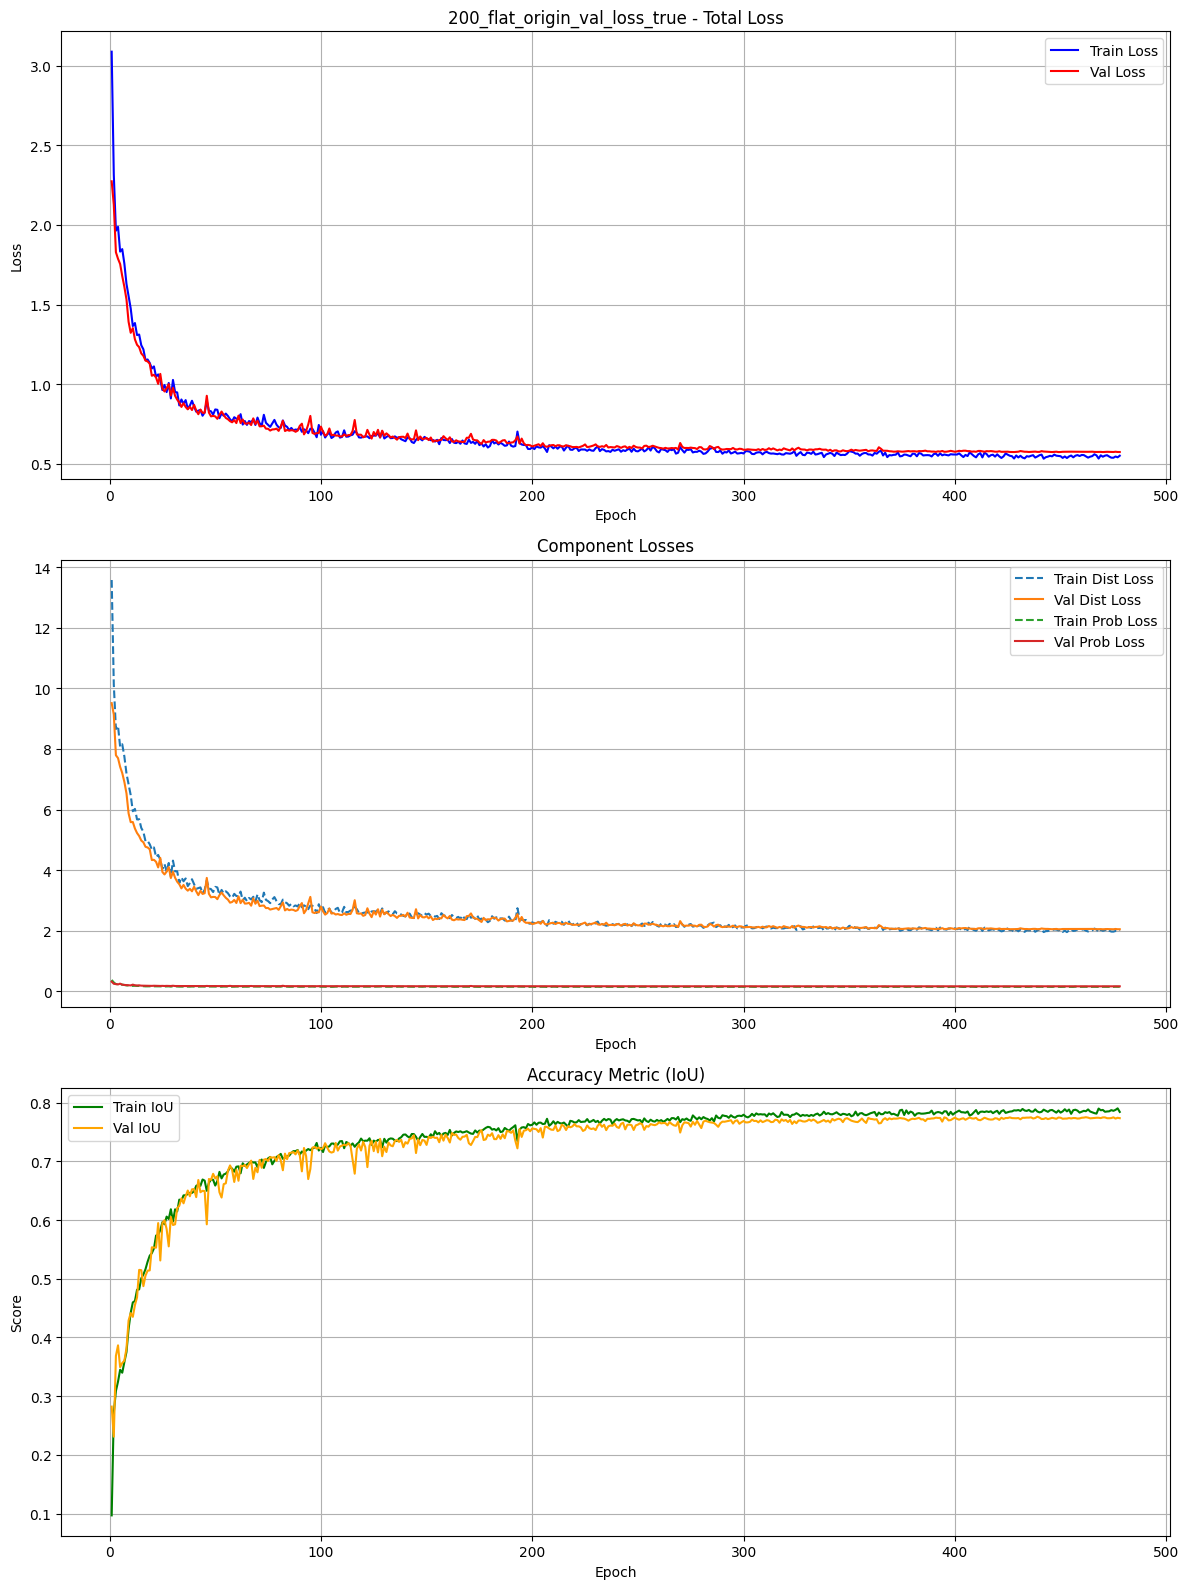

Đã lưu biểu đồ tại: /kaggle/working/models/200_flat_origin_val_loss_true/logs/training_history.png


In [39]:
plot_history(history = history, model_name = model_name, log_dir = LOG_DIR)


In [40]:
model.optimize_thresholds(X_val, Y_val)

NMS threshold = 0.5:  75%|███████▌  | 15/20 [00:30<00:10,  2.03s/it, 0.691 -> 0.844]


Using optimized values: prob_thresh=0.534899, nms_thresh=0.3.
Saving to 'thresholds.json'.


{'prob': 0.5348989963531494, 'nms': 0.3}

Predicting: 100%|██████████| 37/37 [00:08<00:00,  4.35it/s]



✓ Đã predict 37 ảnh validation
Ground Truth:


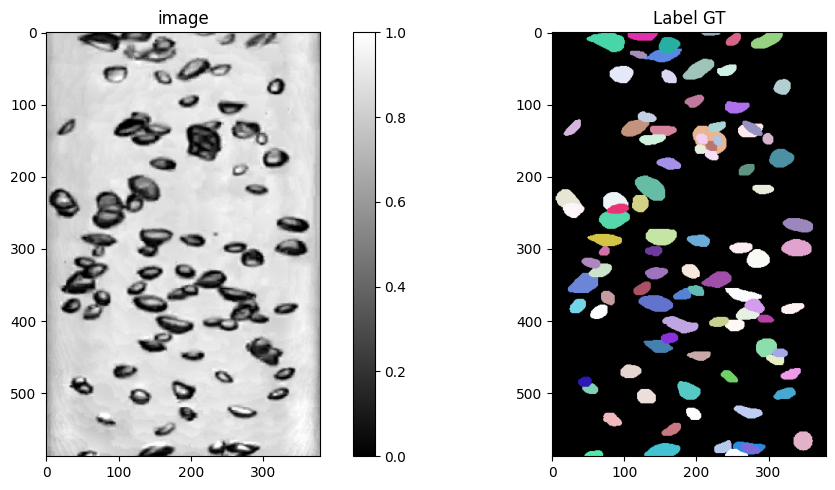


Prediction:


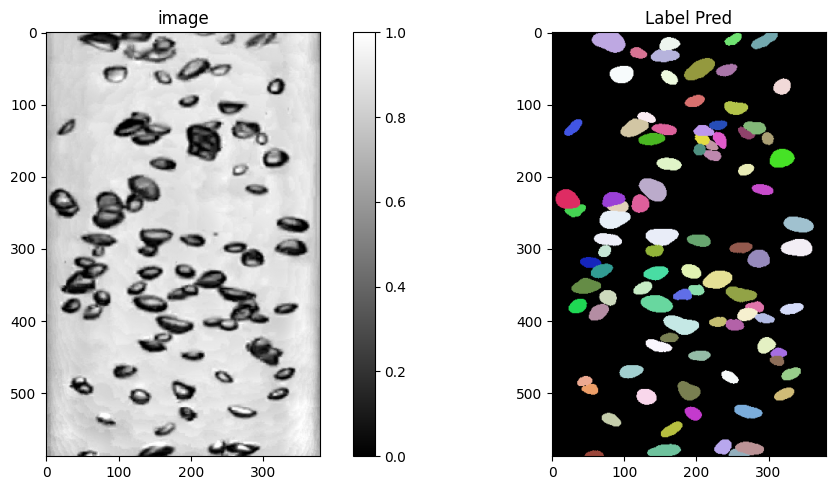

In [41]:
Y_val_pred = valPrediction(model)
plot_GT_Pred(Y_val_pred)

In [42]:
stats = matching_IoUs(Y_val = Y_val, Y_val_pred = Y_val_pred)

Computing matching stats: 100%|██████████| 9/9 [00:03<00:00,  2.95it/s]


KẾT QUẢ ĐÁNH GIÁ

IoU threshold τ = 0.1:
  - Precision: 0.9711
  - Recall:    0.9579
  - F1:        0.9644
  - TP: 2685, FP: 80, FN: 118

IoU threshold τ = 0.2:
  - Precision: 0.9707
  - Recall:    0.9575
  - F1:        0.9641
  - TP: 2684, FP: 81, FN: 119

IoU threshold τ = 0.3:
  - Precision: 0.9696
  - Recall:    0.9565
  - F1:        0.9630
  - TP: 2681, FP: 84, FN: 122

IoU threshold τ = 0.4:
  - Precision: 0.9646
  - Recall:    0.9515
  - F1:        0.9580
  - TP: 2667, FP: 98, FN: 136

IoU threshold τ = 0.5:
  - Precision: 0.9479
  - Recall:    0.9351
  - F1:        0.9415
  - TP: 2621, FP: 144, FN: 182

IoU threshold τ = 0.6:
  - Precision: 0.9197
  - Recall:    0.9072
  - F1:        0.9134
  - TP: 2543, FP: 222, FN: 260

IoU threshold τ = 0.7:
  - Precision: 0.8524
  - Recall:    0.8409
  - F1:        0.8466
  - TP: 2357, FP: 408, FN: 446

IoU threshold τ = 0.8:
  - Precision: 0.6749
  - Recall:    0.6657
  - F1:        0.6703
  - TP: 1866, FP: 899, FN: 937

IoU threshold τ =

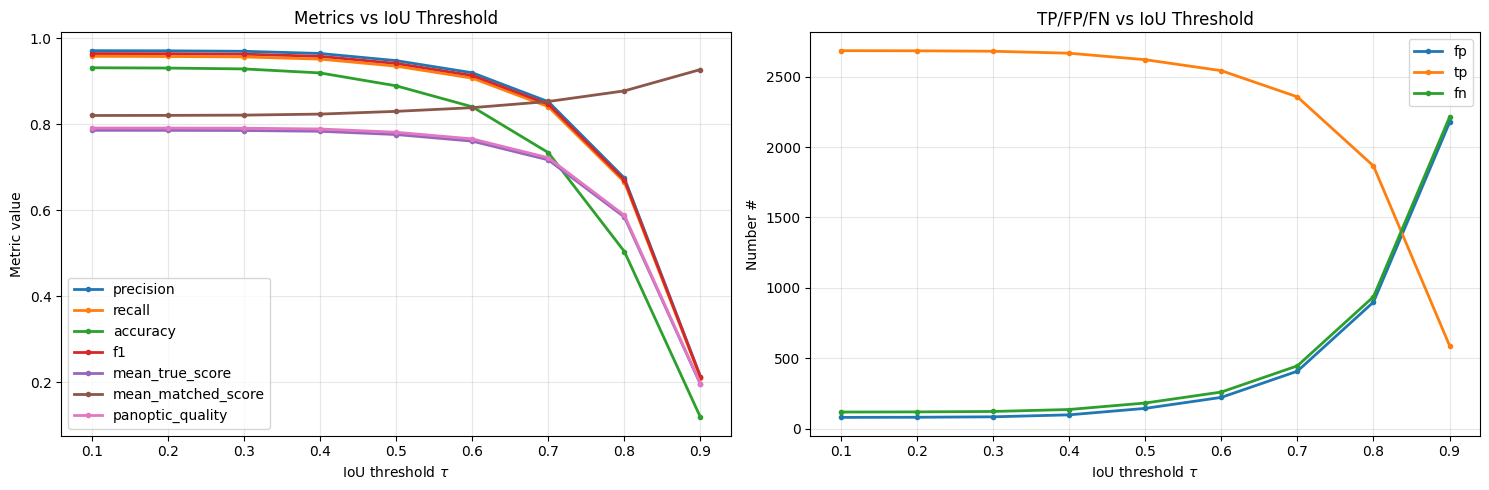


✓ Đã lưu biểu đồ vào /kaggle/working/models/200_flat_origin_val_loss_true/metrics


In [43]:
plot_results_details(stats = stats,model_name = model_name)

In [44]:
# 1. Xóa các biến to
if 'model' in locals():
    del model
if 'history' in locals():
    del history
if 'Y_val_pred' in locals():
    del Y_val_pred
if 'cfg' in locals():
    del cfg
if 'LOG_DIR' in locals():
    del LOG_DIR   
if 'model_name' in locals():
    del model_name  

# 2. Dọn rác
import gc
gc.collect()

# 3. (Nếu dùng GPU) Dọn sạch bộ nhớ GPU cho TensorFlow/Keras
import tensorflow.keras.backend as K
K.clear_session()

# II. val_loss_false

In [45]:
# model name
model_name = MODEL_NAME_1

# Logging Directory
LOG_DIR = os.path.join(MODEL_FOLDER, model_name, 'logs')
if not os.path.exists(LOG_DIR):
    os.makedirs(LOG_DIR)


In [46]:
# Cấu hình mô hình StarDist
cfg = Config2D(
    n_rays=RAYS,
    use_gpu = True,
    n_channel_in = 1,
    unet_n_depth = 3,
    train_patch_size = [256,256],
    unet_pool = [2,2],
    grid = [4,4],
    train_shape_completion = False,
    train_reduce_lr= {"factor": 0.5, "patience": 20, "min_delta": 0.0001}
)

printCfg(cfg)

- configration - Config2D(n_dim=2, axes='YXC', n_channel_in=1, n_channel_out=65, train_checkpoint='weights_best.h5', train_checkpoint_last='weights_last.h5', train_checkpoint_epoch='weights_now.h5', n_rays=64, grid=(4, 4), backbone='unet', n_classes=None, unet_n_depth=3, unet_kernel_size=(3, 3), unet_n_filter_base=32, unet_n_conv_per_depth=2, unet_pool=[2, 2], unet_activation='relu', unet_last_activation='relu', unet_batch_norm=False, unet_dropout=0.0, unet_expansion=2, unet_prefix='', net_conv_after_unet=128, net_input_shape=(None, None, 1), net_mask_shape=(None, None, 1), train_shape_completion=False, train_completion_crop=32, train_patch_size=[256, 256], train_background_reg=0.0001, train_foreground_only=0.9, train_sample_cache=True, train_dist_loss='mae', train_loss_weights=(1, 0.2), train_class_weights=(1, 1), train_epochs=400, train_steps_per_epoch=100, train_learning_rate=0.0003, train_batch_size=4, train_n_val_patches=None, train_tensorboard=True, train_reduce_lr={'factor': 0.5

In [47]:
model = intModel (cfg = cfg, modelName = model_name)


Using default values: prob_thresh=0.5, nms_thresh=0.4.
✓ Tạo model '200_flat_origin_val_loss_true' thành công


base_model.py (203): output path for model already exists, files may be overwritten: /kaggle/working/models/200_flat_origin_val_loss_false


In [48]:
model, history = trainModel(model = model, monitor_metric = 'val_loss', monitor_mode = 'min', X_val = X_val,Y_val = Y_val )

✓ Đã cấu hình EarlyStopping: Monitor 'val_loss' (Mode: min)
✓ Đã cập nhật Callbacks cho Model
Epoch 1/600


2025-12-26 09:57:01.789599: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-26 09:57:01.942387: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-26 09:57:02.241400: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-26 09:57:02.381555: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-26 09:57:03.411519: E external/local_xla/xla/stream_

100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 146ms/step - dist_dist_iou_metric: 0.0433 - dist_loss: 14.8784 - dist_relevant_mae: 14.8782 - dist_relevant_mse: 412.1393 - loss: 3.4012 - prob_kld: 0.3053 - prob_loss: 0.4255 - val_dist_dist_iou_metric: 0.2073 - val_dist_loss: 10.0546 - val_dist_relevant_mae: 10.3926 - val_dist_relevant_mse: 268.8911 - val_loss: 2.3900 - val_prob_kld: 0.1810 - val_prob_loss: 0.3148 - learning_rate: 3.0000e-04
Epoch 2/600
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - dist_dist_iou_metric: 0.2597 - dist_loss: 10.0441 - dist_relevant_mae: 10.0430 - dist_relevant_mse: 220.7943 - loss: 2.2720 - prob_kld: 0.1471 - prob_loss: 0.2631 - val_dist_dist_iou_metric: 0.2154 - val_dist_loss: 9.3055 - val_dist_relevant_mae: 9.5909 - val_dist_relevant_mse: 233.2684 - val_loss: 2.1887 - val_prob_kld: 0.1411 - val_prob_loss: 0.2750 - learning_rate: 3.0000e-04
Epoch 3/600
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - dist_dist_iou_metric: 0.3047 - dist_loss: 9.0608 - dist_relevant_mae: 9.0598

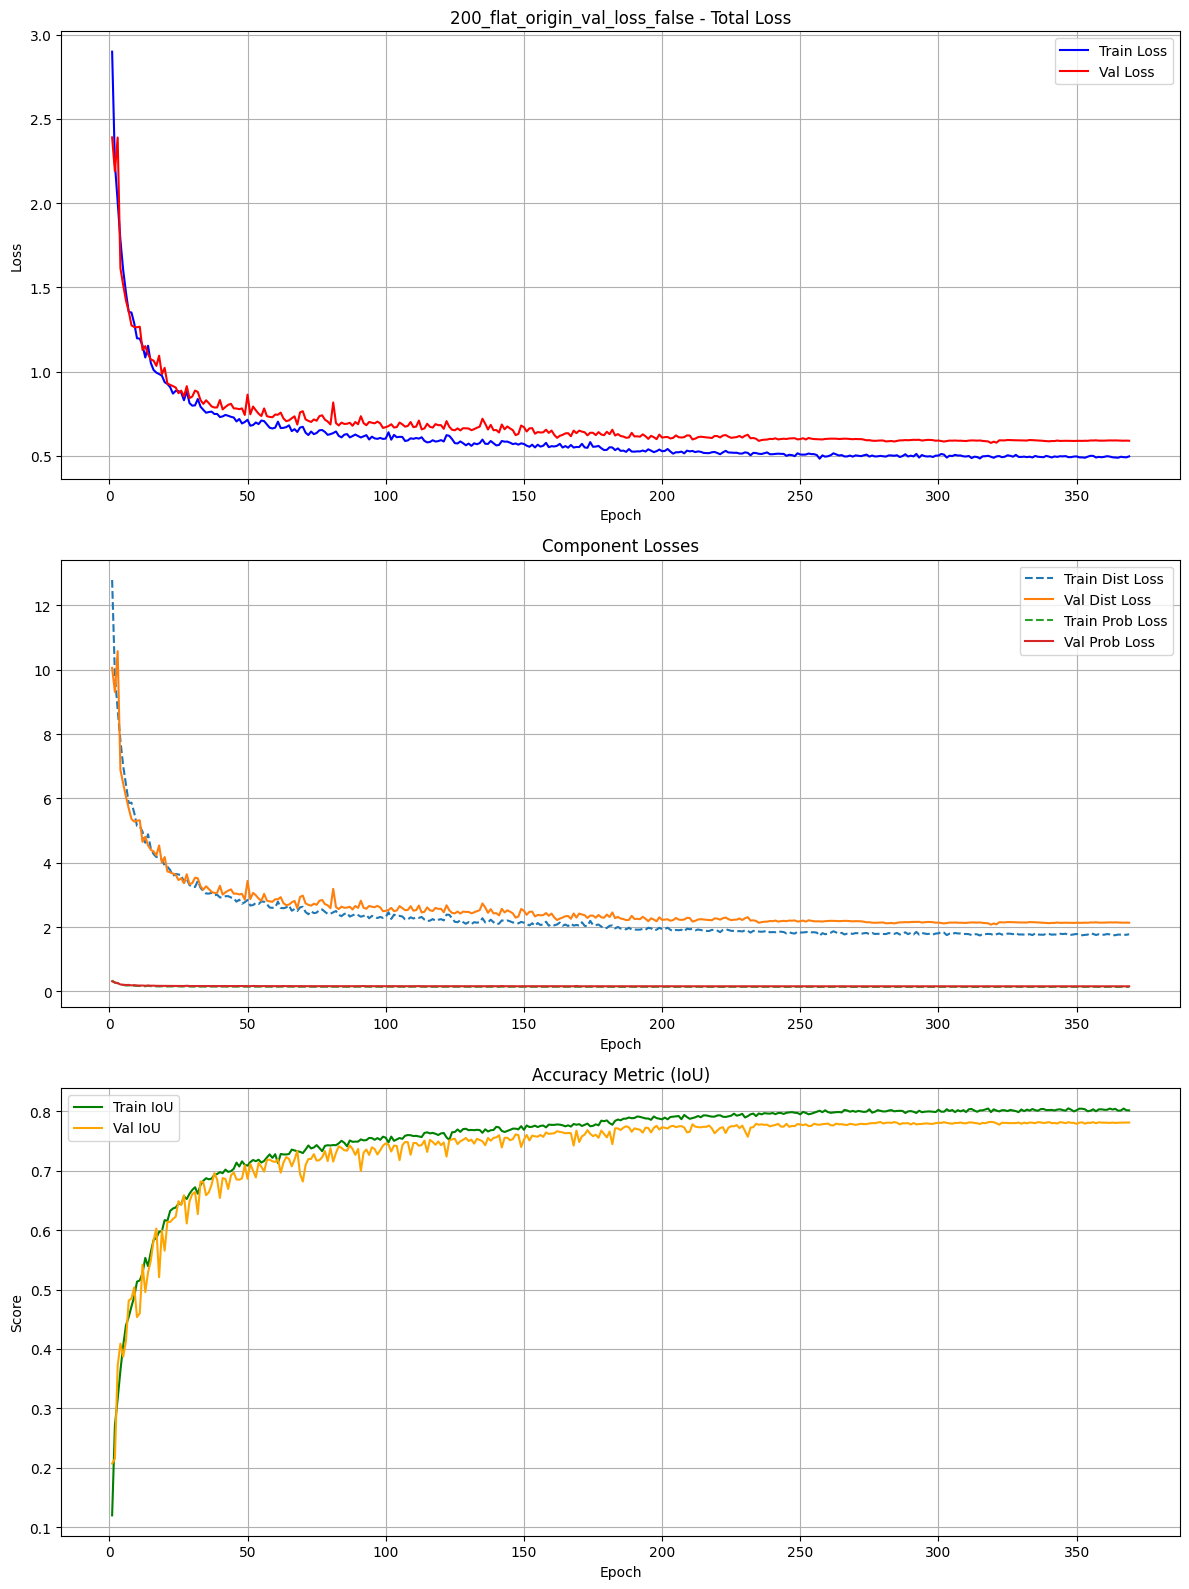

Đã lưu biểu đồ tại: /kaggle/working/models/200_flat_origin_val_loss_false/logs/training_history.png


In [49]:
plot_history(history = history, model_name = model_name, log_dir = LOG_DIR)


In [50]:
model.optimize_thresholds(X_val, Y_val)


NMS threshold = 0.5:  75%|███████▌  | 15/20 [00:31<00:10,  2.09s/it, 0.627 -> 0.853]


Using optimized values: prob_thresh=0.564304, nms_thresh=0.3.
Saving to 'thresholds.json'.


{'prob': 0.5643043518066406, 'nms': 0.3}

Predicting: 100%|██████████| 37/37 [00:08<00:00,  4.27it/s]



✓ Đã predict 37 ảnh validation
Ground Truth:


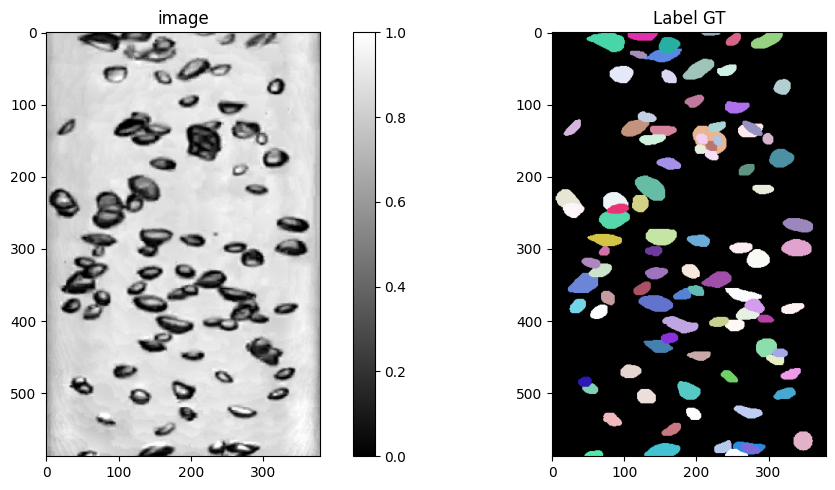


Prediction:


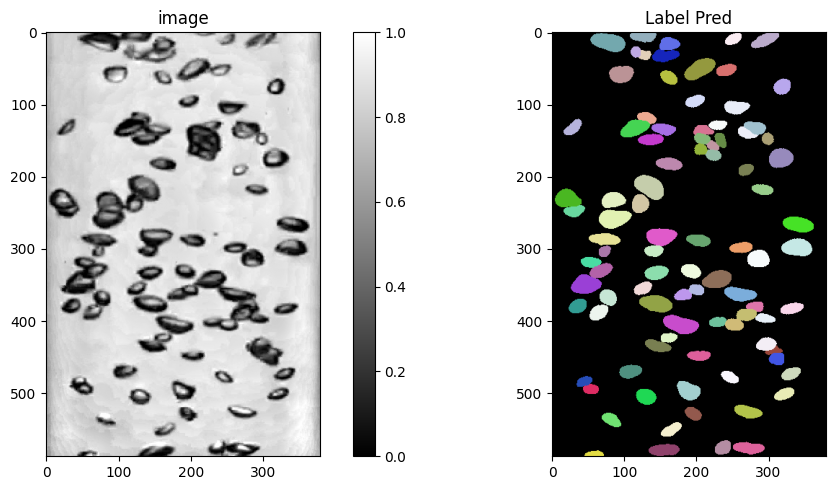

In [51]:
Y_val_pred = valPrediction(model)
plot_GT_Pred(Y_val_pred)

In [52]:
stats = matching_IoUs(Y_val = Y_val, Y_val_pred = Y_val_pred)

Computing matching stats: 100%|██████████| 9/9 [00:03<00:00,  2.98it/s]


KẾT QUẢ ĐÁNH GIÁ

IoU threshold τ = 0.1:
  - Precision: 0.9796
  - Recall:    0.9615
  - F1:        0.9705
  - TP: 2695, FP: 56, FN: 108

IoU threshold τ = 0.2:
  - Precision: 0.9789
  - Recall:    0.9608
  - F1:        0.9698
  - TP: 2693, FP: 58, FN: 110

IoU threshold τ = 0.3:
  - Precision: 0.9767
  - Recall:    0.9586
  - F1:        0.9676
  - TP: 2687, FP: 64, FN: 116

IoU threshold τ = 0.4:
  - Precision: 0.9727
  - Recall:    0.9547
  - F1:        0.9636
  - TP: 2676, FP: 75, FN: 127

IoU threshold τ = 0.5:
  - Precision: 0.9575
  - Recall:    0.9397
  - F1:        0.9485
  - TP: 2634, FP: 117, FN: 169

IoU threshold τ = 0.6:
  - Precision: 0.9324
  - Recall:    0.9151
  - F1:        0.9237
  - TP: 2565, FP: 186, FN: 238

IoU threshold τ = 0.7:
  - Precision: 0.8688
  - Recall:    0.8527
  - F1:        0.8606
  - TP: 2390, FP: 361, FN: 413

IoU threshold τ = 0.8:
  - Precision: 0.6979
  - Recall:    0.6850
  - F1:        0.6914
  - TP: 1920, FP: 831, FN: 883

IoU threshold τ =

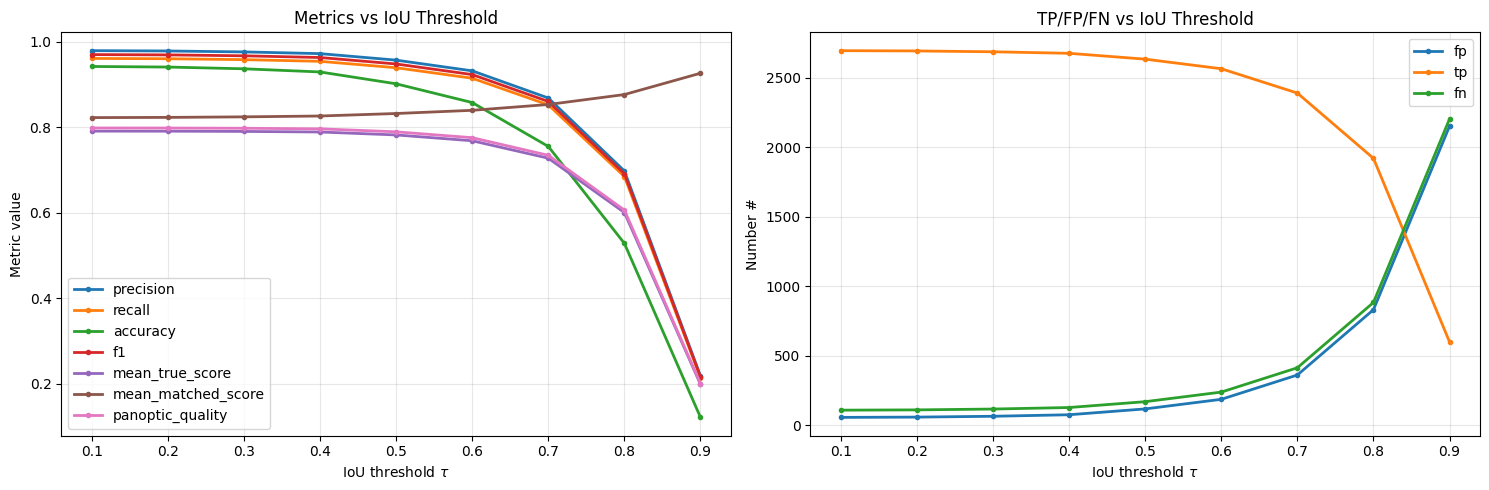


✓ Đã lưu biểu đồ vào /kaggle/working/models/200_flat_origin_val_loss_false/metrics


In [53]:
plot_results_details(stats = stats,model_name = model_name)

In [54]:
# 1. Xóa các biến to
if 'model' in locals():
    del model
if 'history' in locals():
    del history
if 'Y_val_pred' in locals():
    del Y_val_pred
if 'cfg' in locals():
    del cfg
if 'LOG_DIR' in locals():
    del LOG_DIR   
if 'model_name' in locals():
    del model_name  

# 2. Dọn rác
import gc
gc.collect()

# 3. (Nếu dùng GPU) Dọn sạch bộ nhớ GPU cho TensorFlow/Keras
import tensorflow.keras.backend as K
K.clear_session()

# III. dist_dist_iou_metric_true

In [55]:
# model name
model_name = MODEL_NAME_2

# Logging Directory
LOG_DIR = os.path.join(MODEL_FOLDER, model_name, 'logs')
if not os.path.exists(LOG_DIR):
    os.makedirs(LOG_DIR)


In [56]:
# Cấu hình mô hình StarDist
cfg = Config2D(
    n_rays=RAYS,
    use_gpu = True,
    n_channel_in = 1,
    unet_n_depth = 3,
    train_patch_size = [256,256],
    unet_pool = [2,2],
    grid = [4,4],
    train_shape_completion = True,
    train_reduce_lr= {"factor": 0.5, "patience": 20, "min_delta": 0.0001}
)

printCfg(cfg)

- configration - Config2D(n_dim=2, axes='YXC', n_channel_in=1, n_channel_out=65, train_checkpoint='weights_best.h5', train_checkpoint_last='weights_last.h5', train_checkpoint_epoch='weights_now.h5', n_rays=64, grid=(4, 4), backbone='unet', n_classes=None, unet_n_depth=3, unet_kernel_size=(3, 3), unet_n_filter_base=32, unet_n_conv_per_depth=2, unet_pool=[2, 2], unet_activation='relu', unet_last_activation='relu', unet_batch_norm=False, unet_dropout=0.0, unet_expansion=2, unet_prefix='', net_conv_after_unet=128, net_input_shape=(None, None, 1), net_mask_shape=(None, None, 1), train_shape_completion=True, train_completion_crop=32, train_patch_size=[256, 256], train_background_reg=0.0001, train_foreground_only=0.9, train_sample_cache=True, train_dist_loss='mae', train_loss_weights=(1, 0.2), train_class_weights=(1, 1), train_epochs=400, train_steps_per_epoch=100, train_learning_rate=0.0003, train_batch_size=4, train_n_val_patches=None, train_tensorboard=True, train_reduce_lr={'factor': 0.5,

In [57]:
model = intModel (cfg = cfg, modelName = model_name)


Using default values: prob_thresh=0.5, nms_thresh=0.4.
✓ Tạo model '200_flat_origin_val_loss_true' thành công


base_model.py (203): output path for model already exists, files may be overwritten: /kaggle/working/models/200_flat_origin_dist_dist_iou_metric_true


In [58]:
model, history = trainModel(model = model, monitor_metric = 'val_dist_dist_iou_metric', monitor_mode = 'max', X_val = X_val,Y_val = Y_val )

✓ Đã cấu hình EarlyStopping: Monitor 'val_dist_dist_iou_metric' (Mode: max)
✓ Đã cập nhật Callbacks cho Model
Epoch 1/600
100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 180ms/step - dist_dist_iou_metric: 0.0392 - dist_loss: 14.5247 - dist_relevant_mae: 14.5245 - dist_relevant_mse: 371.2686 - loss: 3.3447 - prob_kld: 0.3212 - prob_loss: 0.4398 - val_dist_dist_iou_metric: 0.2574 - val_dist_loss: 10.0189 - val_dist_relevant_mae: 9.5866 - val_dist_relevant_mse: 211.1518 - val_loss: 2.2707 - val_prob_kld: 0.2097 - val_prob_loss: 0.3485 - learning_rate: 3.0000e-04
Epoch 2/600
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - dist_dist_iou_metric: 0.2792 - dist_loss: 9.6131 - dist_relevant_mae: 9.6120 - dist_relevant_mse: 194.0391 - loss: 2.1883 - prob_kld: 0.1501 - prob_loss: 0.2657 - val_dist_dist_iou_metric: 0.2189 - val_dist_loss: 9.8763 - val_dist_relevant_mae: 9.4012 - val_dist_relevant_mse: 204.1642 - val_loss: 2.1921 - val_prob_kld: 0.1670 - val_prob_loss: 0.3059 - learning_rate: 3.0000e-04
Epoch 3/600
1

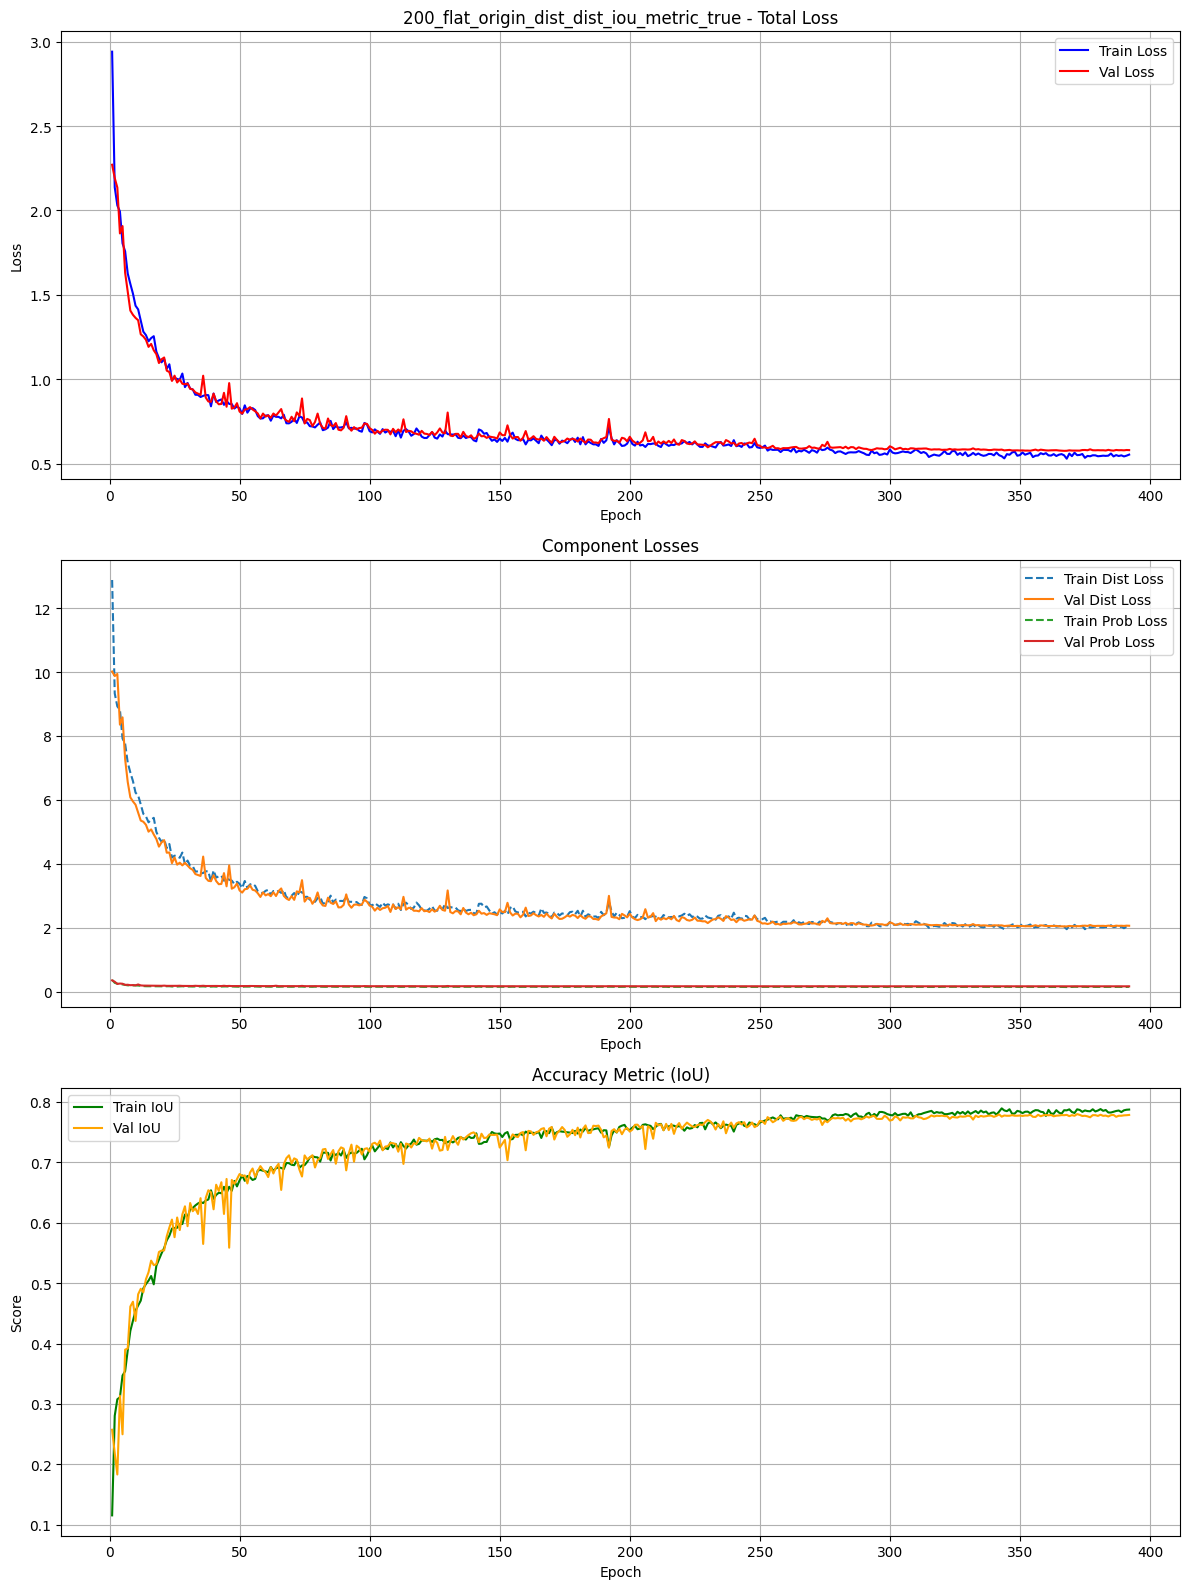

Đã lưu biểu đồ tại: /kaggle/working/models/200_flat_origin_dist_dist_iou_metric_true/logs/training_history.png


In [59]:
plot_history(history = history, model_name = model_name, log_dir = LOG_DIR)


In [60]:
model.optimize_thresholds(X_val, Y_val)


NMS threshold = 0.5:  75%|███████▌  | 15/20 [00:30<00:10,  2.01s/it, 0.721 -> 0.844]


Using optimized values: prob_thresh=0.584551, nms_thresh=0.3.
Saving to 'thresholds.json'.


{'prob': 0.5845507383346558, 'nms': 0.3}

Predicting: 100%|██████████| 37/37 [00:08<00:00,  4.24it/s]



✓ Đã predict 37 ảnh validation
Ground Truth:


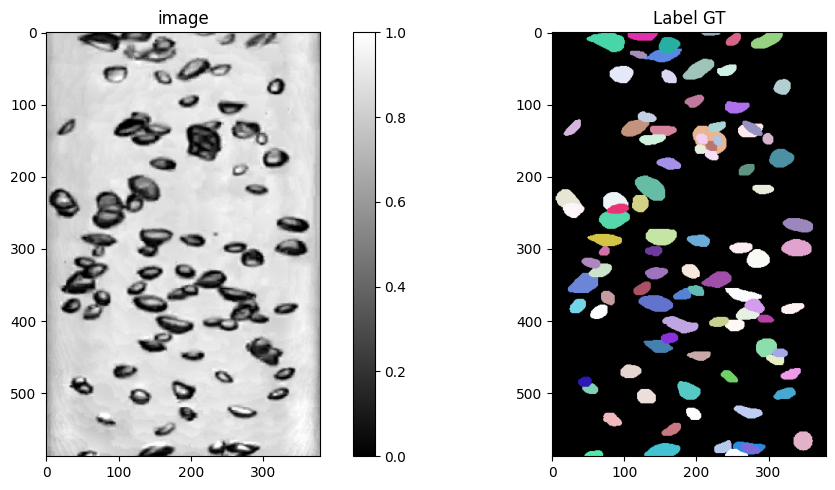


Prediction:


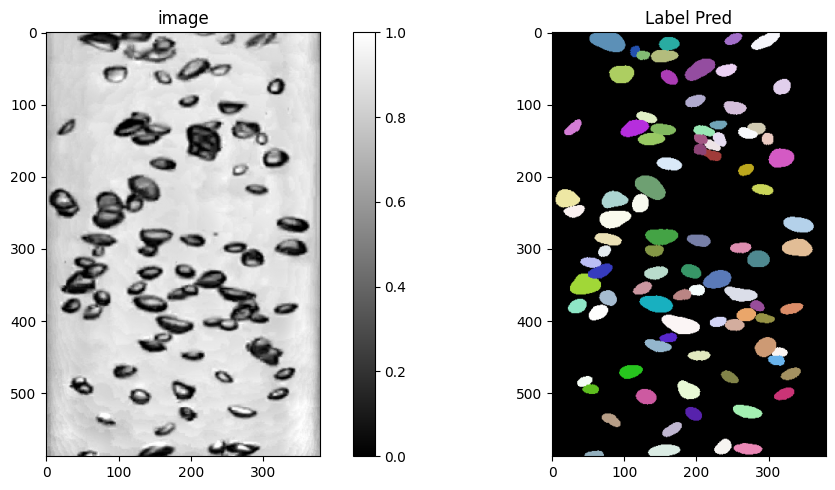

In [61]:
Y_val_pred = valPrediction(model)
plot_GT_Pred(Y_val_pred)

In [62]:
stats = matching_IoUs(Y_val = Y_val, Y_val_pred = Y_val_pred)

Computing matching stats: 100%|██████████| 9/9 [00:03<00:00,  3.00it/s]


KẾT QUẢ ĐÁNH GIÁ

IoU threshold τ = 0.1:
  - Precision: 0.9756
  - Recall:    0.9575
  - F1:        0.9665
  - TP: 2684, FP: 67, FN: 119

IoU threshold τ = 0.2:
  - Precision: 0.9753
  - Recall:    0.9572
  - F1:        0.9662
  - TP: 2683, FP: 68, FN: 120

IoU threshold τ = 0.3:
  - Precision: 0.9731
  - Recall:    0.9550
  - F1:        0.9640
  - TP: 2677, FP: 74, FN: 126

IoU threshold τ = 0.4:
  - Precision: 0.9662
  - Recall:    0.9483
  - F1:        0.9571
  - TP: 2658, FP: 93, FN: 145

IoU threshold τ = 0.5:
  - Precision: 0.9520
  - Recall:    0.9344
  - F1:        0.9431
  - TP: 2619, FP: 132, FN: 184

IoU threshold τ = 0.6:
  - Precision: 0.9182
  - Recall:    0.9012
  - F1:        0.9096
  - TP: 2526, FP: 225, FN: 277

IoU threshold τ = 0.7:
  - Precision: 0.8550
  - Recall:    0.8391
  - F1:        0.8470
  - TP: 2352, FP: 399, FN: 451

IoU threshold τ = 0.8:
  - Precision: 0.6736
  - Recall:    0.6611
  - F1:        0.6673
  - TP: 1853, FP: 898, FN: 950

IoU threshold τ =

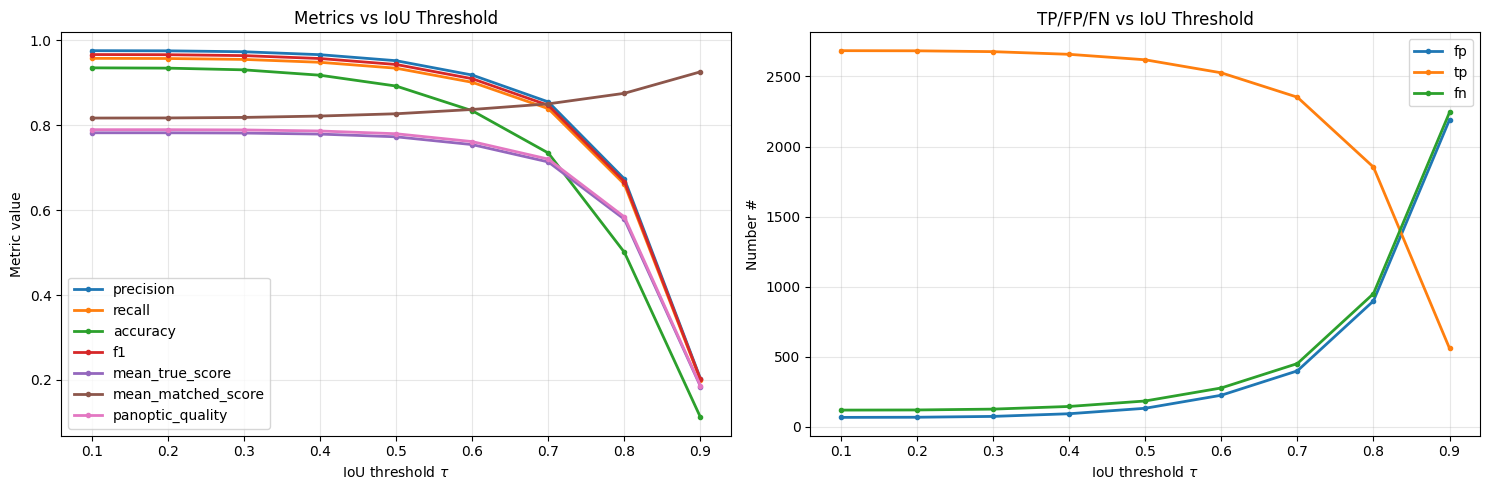


✓ Đã lưu biểu đồ vào /kaggle/working/models/200_flat_origin_dist_dist_iou_metric_true/metrics


In [63]:
plot_results_details(stats = stats,model_name = model_name)

In [64]:
# 1. Xóa các biến to
if 'model' in locals():
    del model
if 'history' in locals():
    del history
if 'Y_val_pred' in locals():
    del Y_val_pred
if 'cfg' in locals():
    del cfg
if 'LOG_DIR' in locals():
    del LOG_DIR   
if 'model_name' in locals():
    del model_name  

# 2. Dọn rác
import gc
gc.collect()

# 3. (Nếu dùng GPU) Dọn sạch bộ nhớ GPU cho TensorFlow/Keras
import tensorflow.keras.backend as K
K.clear_session()

# IV. dist_dist_iou_metric_false

In [65]:
# model name
model_name = MODEL_NAME_3

# Logging Directory
LOG_DIR = os.path.join(MODEL_FOLDER, model_name, 'logs')
if not os.path.exists(LOG_DIR):
    os.makedirs(LOG_DIR)


In [66]:
# Cấu hình mô hình StarDist
cfg = Config2D(
    n_rays=RAYS,
    use_gpu = True,
    n_channel_in = 1,
    unet_n_depth = 3,
    train_patch_size = [256,256],
    unet_pool = [2,2],
    grid = [4,4],
    train_shape_completion = False,
    train_reduce_lr= {"factor": 0.5, "patience": 20, "min_delta": 0.0001}
)

printCfg(cfg)

- configration - Config2D(n_dim=2, axes='YXC', n_channel_in=1, n_channel_out=65, train_checkpoint='weights_best.h5', train_checkpoint_last='weights_last.h5', train_checkpoint_epoch='weights_now.h5', n_rays=64, grid=(4, 4), backbone='unet', n_classes=None, unet_n_depth=3, unet_kernel_size=(3, 3), unet_n_filter_base=32, unet_n_conv_per_depth=2, unet_pool=[2, 2], unet_activation='relu', unet_last_activation='relu', unet_batch_norm=False, unet_dropout=0.0, unet_expansion=2, unet_prefix='', net_conv_after_unet=128, net_input_shape=(None, None, 1), net_mask_shape=(None, None, 1), train_shape_completion=False, train_completion_crop=32, train_patch_size=[256, 256], train_background_reg=0.0001, train_foreground_only=0.9, train_sample_cache=True, train_dist_loss='mae', train_loss_weights=(1, 0.2), train_class_weights=(1, 1), train_epochs=400, train_steps_per_epoch=100, train_learning_rate=0.0003, train_batch_size=4, train_n_val_patches=None, train_tensorboard=True, train_reduce_lr={'factor': 0.5

In [67]:
model = intModel (cfg = cfg, modelName = model_name)


Using default values: prob_thresh=0.5, nms_thresh=0.4.
✓ Tạo model '200_flat_origin_val_loss_true' thành công


base_model.py (203): output path for model already exists, files may be overwritten: /kaggle/working/models/200_flat_origin_dist_dist_iou_metric_false


In [68]:
model, history = trainModel(model = model, monitor_metric = 'val_dist_dist_iou_metric', monitor_mode = 'max', X_val = X_val,Y_val = Y_val )

✓ Đã cấu hình EarlyStopping: Monitor 'val_dist_dist_iou_metric' (Mode: max)
✓ Đã cập nhật Callbacks cho Model
Epoch 1/600
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 132ms/step - dist_dist_iou_metric: 0.0512 - dist_loss: 14.4449 - dist_relevant_mae: 14.4446 - dist_relevant_mse: 394.7689 - loss: 3.3272 - prob_kld: 0.3186 - prob_loss: 0.4382 - val_dist_dist_iou_metric: 0.2491 - val_dist_loss: 9.8433 - val_dist_relevant_mae: 9.4685 - val_dist_relevant_mse: 221.3337 - val_loss: 2.4212 - val_prob_kld: 0.4002 - val_prob_loss: 0.5242 - learning_rate: 3.0000e-04
Epoch 2/600
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - dist_dist_iou_metric: 0.2681 - dist_loss: 9.9112 - dist_relevant_mae: 9.9102 - dist_relevant_mse: 219.7989 - loss: 2.3562 - prob_kld: 0.2523 - prob_loss: 0.3740 - val_dist_dist_iou_metric: 0.2425 - val_dist_loss: 9.6223 - val_dist_relevant_mae: 9.2294 - val_dist_relevant_mse: 211.1055 - val_loss: 2.1235 - val_prob_kld: 0.1465 - val_prob_loss: 0.2705 - learning_rate: 3.0000e-04
Epoch 3/600
10

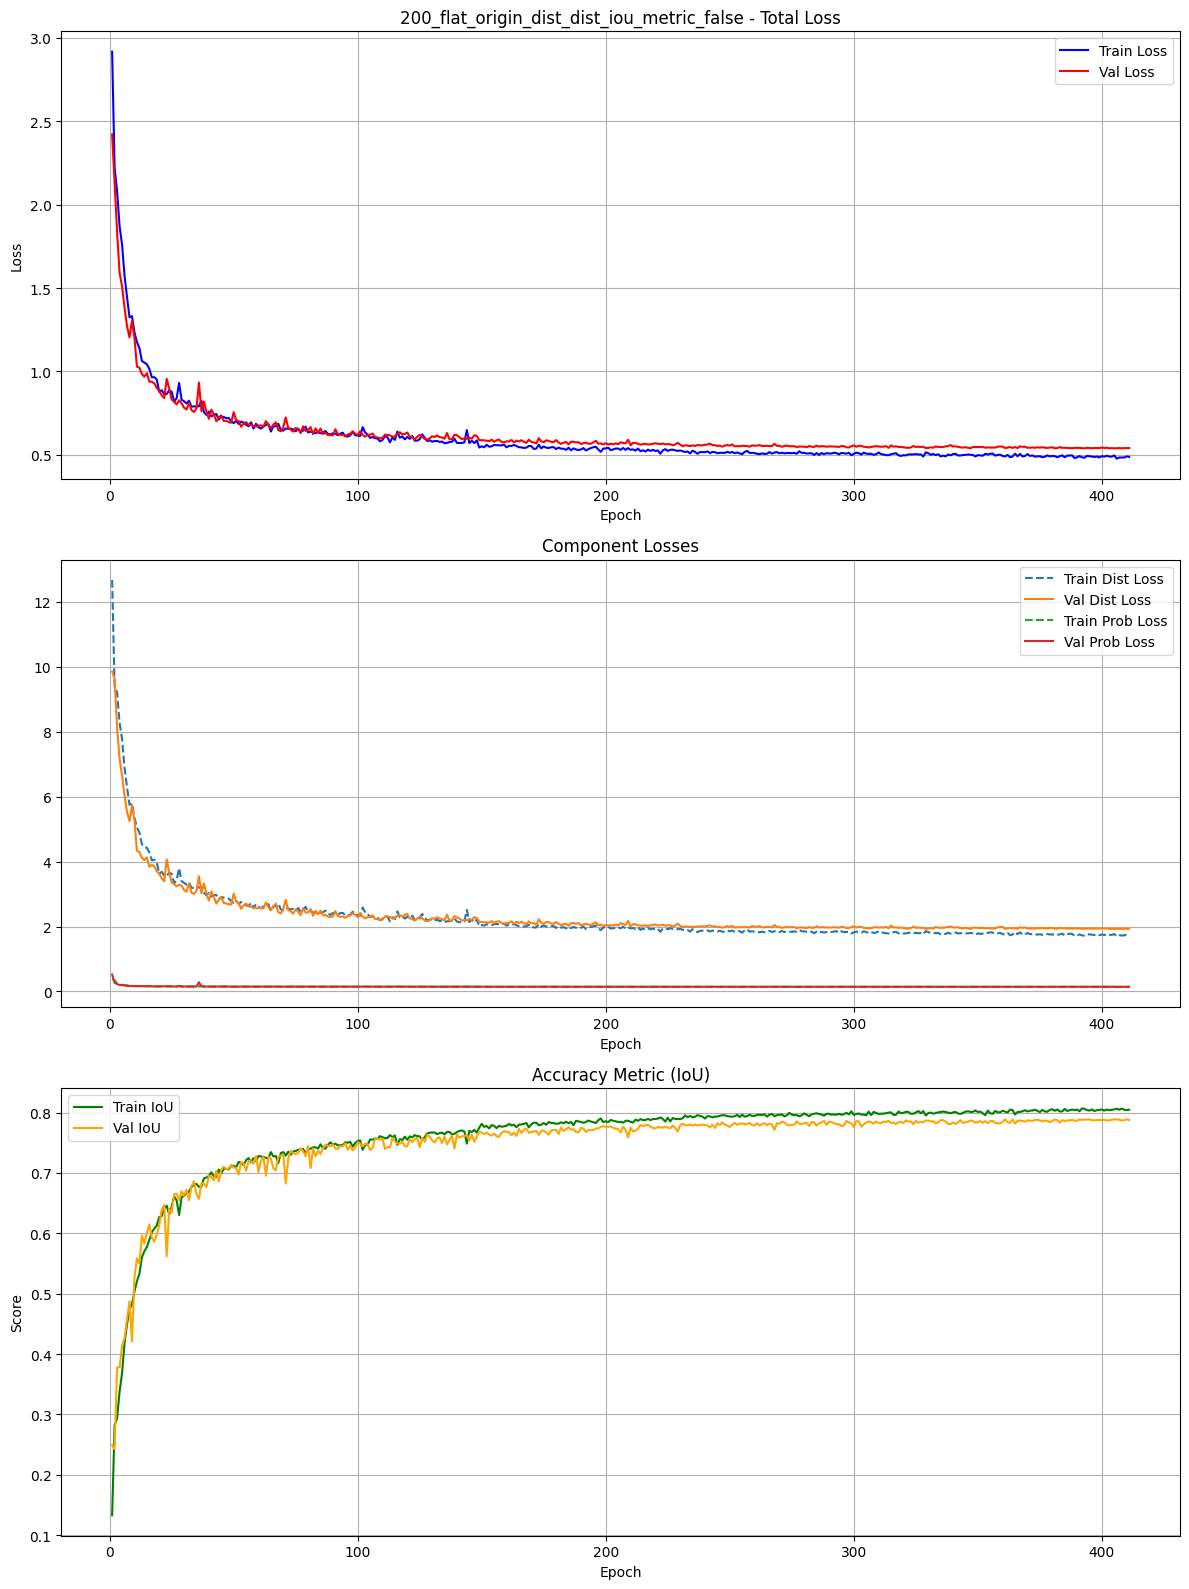

Đã lưu biểu đồ tại: /kaggle/working/models/200_flat_origin_dist_dist_iou_metric_false/logs/training_history.png


In [69]:
plot_history(history = history, model_name = model_name, log_dir = LOG_DIR)


In [70]:
model.optimize_thresholds(X_val, Y_val)


NMS threshold = 0.5:  75%|███████▌  | 15/20 [00:31<00:10,  2.10s/it, 0.660 -> 0.855]


Using optimized values: prob_thresh=0.63106, nms_thresh=0.3.
Saving to 'thresholds.json'.


{'prob': 0.6310603618621826, 'nms': 0.3}

Predicting: 100%|██████████| 37/37 [00:08<00:00,  4.32it/s]



✓ Đã predict 37 ảnh validation
Ground Truth:


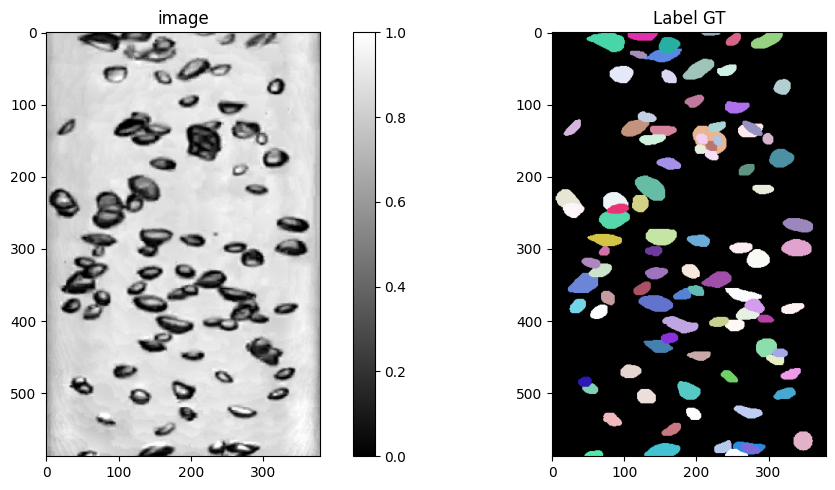


Prediction:


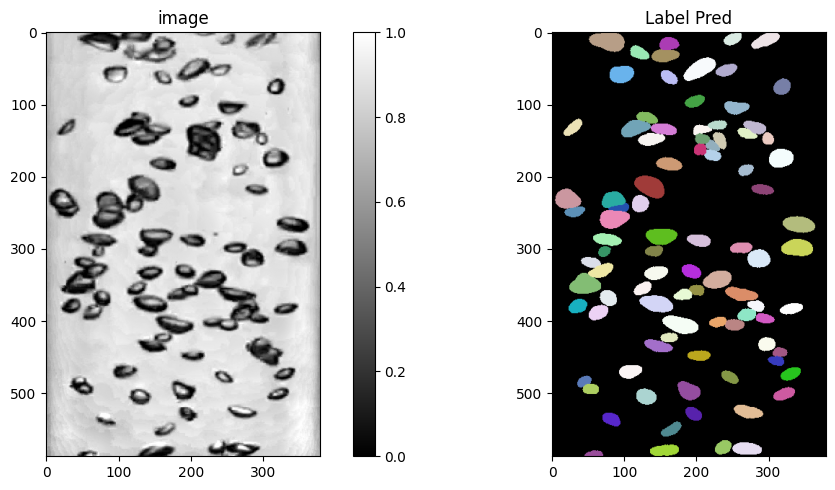

In [71]:
Y_val_pred = valPrediction(model)
plot_GT_Pred(Y_val_pred)

In [72]:
stats = matching_IoUs(Y_val = Y_val, Y_val_pred = Y_val_pred)

Computing matching stats: 100%|██████████| 9/9 [00:03<00:00,  2.91it/s]


KẾT QUẢ ĐÁNH GIÁ

IoU threshold τ = 0.1:
  - Precision: 0.9821
  - Recall:    0.9575
  - F1:        0.9697
  - TP: 2684, FP: 49, FN: 119

IoU threshold τ = 0.2:
  - Precision: 0.9806
  - Recall:    0.9561
  - F1:        0.9682
  - TP: 2680, FP: 53, FN: 123

IoU threshold τ = 0.3:
  - Precision: 0.9784
  - Recall:    0.9540
  - F1:        0.9660
  - TP: 2674, FP: 59, FN: 129

IoU threshold τ = 0.4:
  - Precision: 0.9740
  - Recall:    0.9497
  - F1:        0.9617
  - TP: 2662, FP: 71, FN: 141

IoU threshold τ = 0.5:
  - Precision: 0.9605
  - Recall:    0.9365
  - F1:        0.9483
  - TP: 2625, FP: 108, FN: 178

IoU threshold τ = 0.6:
  - Precision: 0.9276
  - Recall:    0.9044
  - F1:        0.9158
  - TP: 2535, FP: 198, FN: 268

IoU threshold τ = 0.7:
  - Precision: 0.8716
  - Recall:    0.8498
  - F1:        0.8605
  - TP: 2382, FP: 351, FN: 421

IoU threshold τ = 0.8:
  - Precision: 0.7080
  - Recall:    0.6903
  - F1:        0.6991
  - TP: 1935, FP: 798, FN: 868

IoU threshold τ =

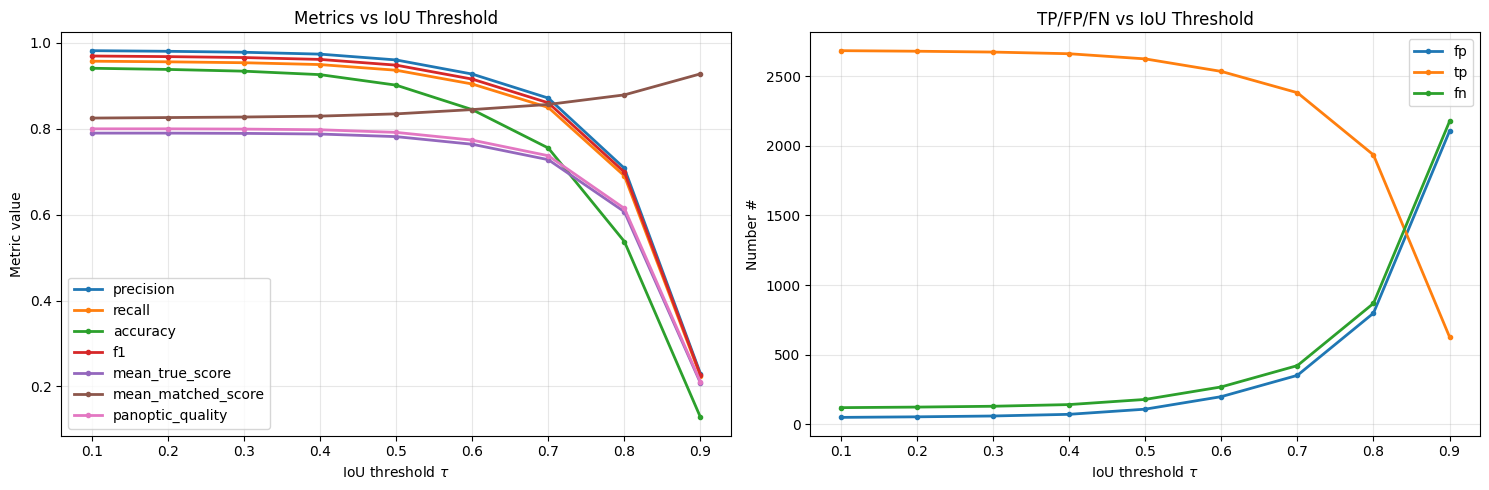


✓ Đã lưu biểu đồ vào /kaggle/working/models/200_flat_origin_dist_dist_iou_metric_false/metrics


In [73]:
plot_results_details(stats = stats,model_name = model_name)

In [74]:
# 1. Xóa các biến to
if 'model' in locals():
    del model
if 'history' in locals():
    del history
if 'Y_val_pred' in locals():
    del Y_val_pred
if 'cfg' in locals():
    del cfg
if 'LOG_DIR' in locals():
    del LOG_DIR   
if 'model_name' in locals():
    del model_name  

# 2. Dọn rác
import gc
gc.collect()

# 3. (Nếu dùng GPU) Dọn sạch bộ nhớ GPU cho TensorFlow/Keras
import tensorflow.keras.backend as K
K.clear_session()

# V. Paper

In [75]:
# model name
model_name = MODEL_NAME_1

# Logging Directory
LOG_DIR = os.path.join(MODEL_FOLDER, model_name, 'logs')
if not os.path.exists(LOG_DIR):
    os.makedirs(LOG_DIR)

In [76]:
# Cấu hình mô hình StarDist

with open('/kaggle/input/cfg-paper/config.json') as f:
    cfg_dict = json.load(f)

cfg = Config2D(**cfg_dict)
cfg.train_patch_size = [256,256]
cfg.use_gpu =  True

printCfg(cfg)

- configration - Config2D(n_dim=2, axes='YXC', n_channel_in=1, n_channel_out=65, train_checkpoint='weights_best.h5', train_checkpoint_last='weights_last.h5', train_checkpoint_epoch='weights_now.h5', n_rays=64, grid=(4, 8), backbone='unet', n_classes=None, unet_n_depth=3, unet_kernel_size=[3, 3], unet_n_filter_base=32, unet_n_conv_per_depth=2, unet_pool=[2, 2], unet_activation='relu', unet_last_activation='relu', unet_batch_norm=False, unet_dropout=0, unet_expansion=2, unet_prefix='', net_conv_after_unet=128, net_input_shape=[None, None, 1], net_mask_shape=[None, None, 1], train_shape_completion=True, train_completion_crop=32, train_patch_size=[256, 256], train_background_reg=0.0001, train_foreground_only=0.9, train_sample_cache=True, train_dist_loss='mae', train_loss_weights=[1, 0.2], train_class_weights=[1, 1], train_epochs=400, train_steps_per_epoch=100, train_learning_rate=0.0002, train_batch_size=4, train_n_val_patches=None, train_tensorboard=True, train_reduce_lr={'factor': 0.5, '

In [77]:
model = intModel (cfg = cfg, modelName = model_name)


Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.564304, nms_thresh=0.3.
✓ Tạo model '200_flat_origin_val_loss_true' thành công


In [78]:
model, history = trainModel(model = model, monitor_metric = 'val_loss', monitor_mode = 'min', X_val = X_val,Y_val = Y_val )

✓ Đã cấu hình EarlyStopping: Monitor 'val_loss' (Mode: min)
✓ Đã cập nhật Callbacks cho Model
Epoch 1/600
100/100 ━━━━━━━━━━━━━━━━━━━━ 36s 197ms/step - dist_dist_iou_metric: 0.0161 - dist_loss: 14.8708 - dist_relevant_mae: 14.8707 - dist_relevant_mse: 395.9075 - loss: 3.4728 - prob_kld: 0.3932 - prob_loss: 0.4986 - val_dist_dist_iou_metric: 0.1152 - val_dist_loss: 10.8154 - val_dist_relevant_mae: 11.1442 - val_dist_relevant_mse: 276.8503 - val_loss: 2.6305 - val_prob_kld: 0.2739 - val_prob_loss: 0.4046 - learning_rate: 2.0000e-04
Epoch 2/600
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - dist_dist_iou_metric: 0.2222 - dist_loss: 9.6768 - dist_relevant_mae: 9.6759 - dist_relevant_mse: 194.2225 - loss: 2.2879 - prob_kld: 0.2492 - prob_loss: 0.3525 - val_dist_dist_iou_metric: 0.2544 - val_dist_loss: 8.7216 - val_dist_relevant_mae: 8.9796 - val_dist_relevant_mse: 189.3520 - val_loss: 2.0951 - val_prob_kld: 0.1699 - val_prob_loss: 0.3006 - learning_rate: 2.0000e-04
Epoch 3/600
100/100 ━━━━━━━━

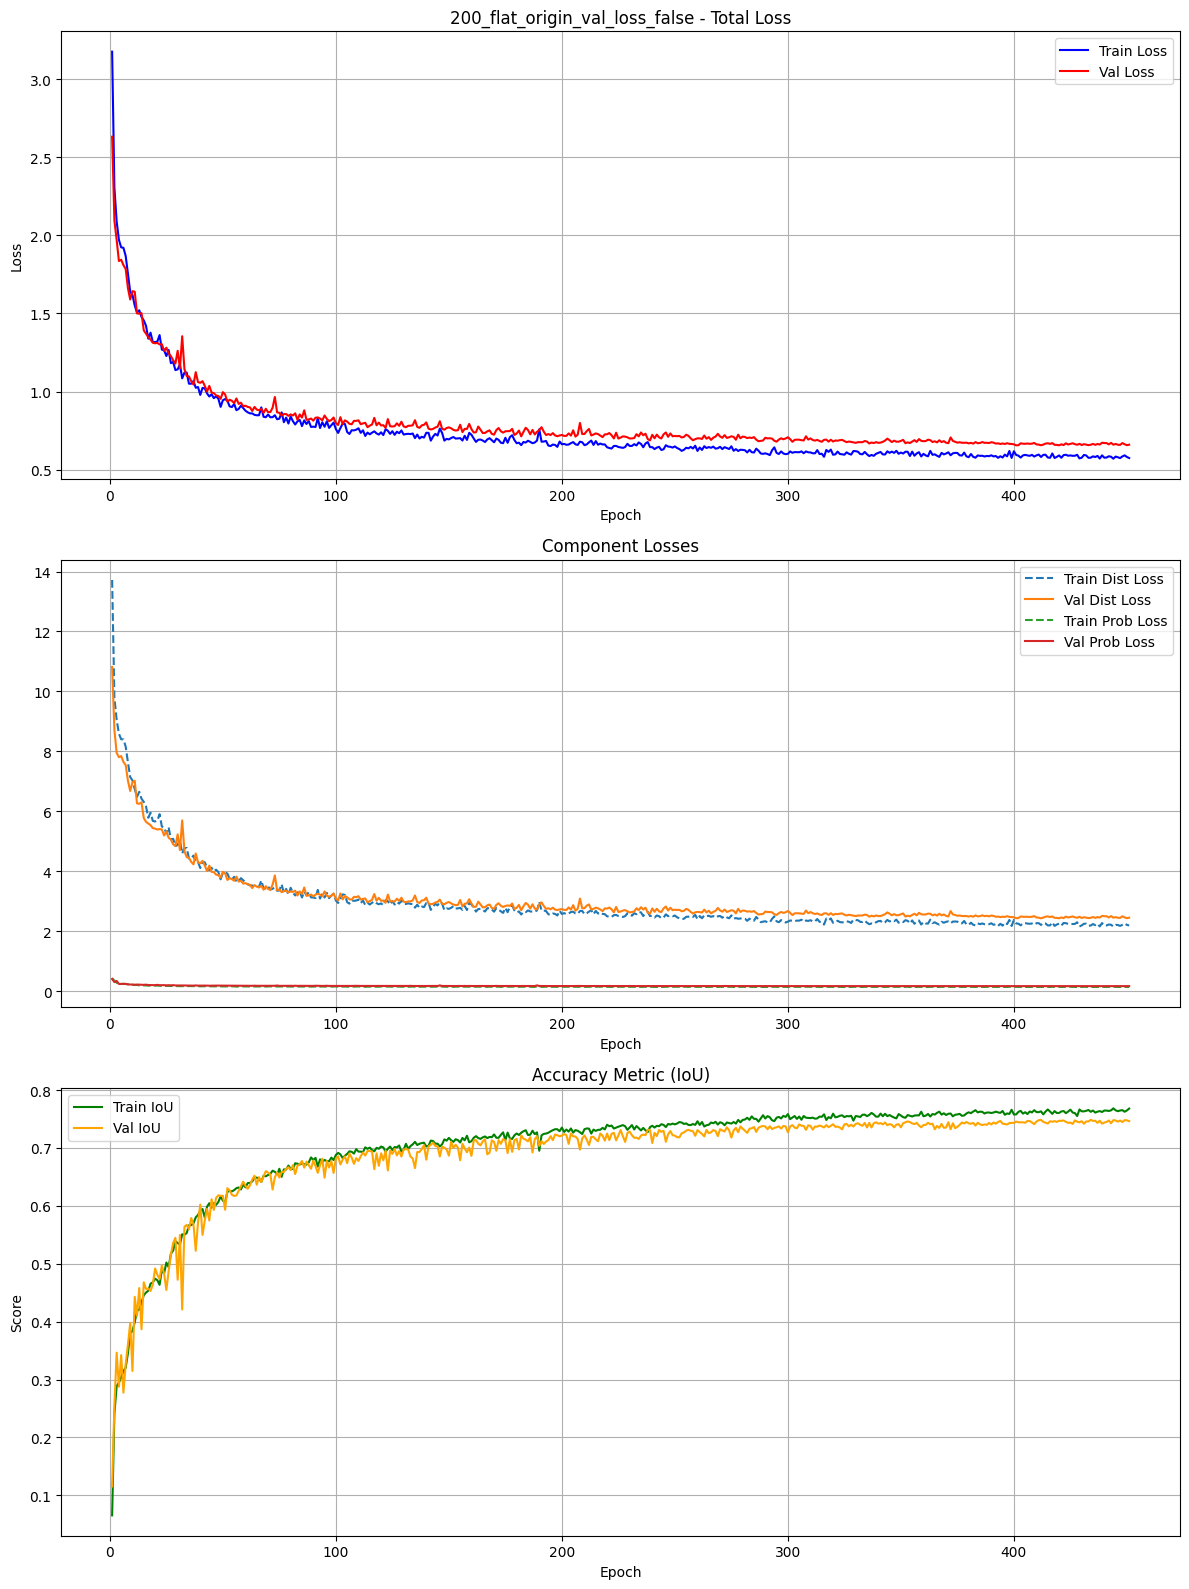

Đã lưu biểu đồ tại: /kaggle/working/models/200_flat_origin_val_loss_false/logs/training_history.png


In [79]:
plot_history(history = history, model_name = model_name, log_dir = LOG_DIR)


In [80]:
model.optimize_thresholds(X_val, Y_val)


NMS threshold = 0.5:  75%|███████▌  | 15/20 [00:28<00:09,  1.92s/it, 0.682 -> 0.838]


Using optimized values: prob_thresh=0.658625, nms_thresh=0.3.
Saving to 'thresholds.json'.


{'prob': 0.6586247682571411, 'nms': 0.3}

Predicting: 100%|██████████| 37/37 [00:08<00:00,  4.37it/s]



✓ Đã predict 37 ảnh validation
Ground Truth:


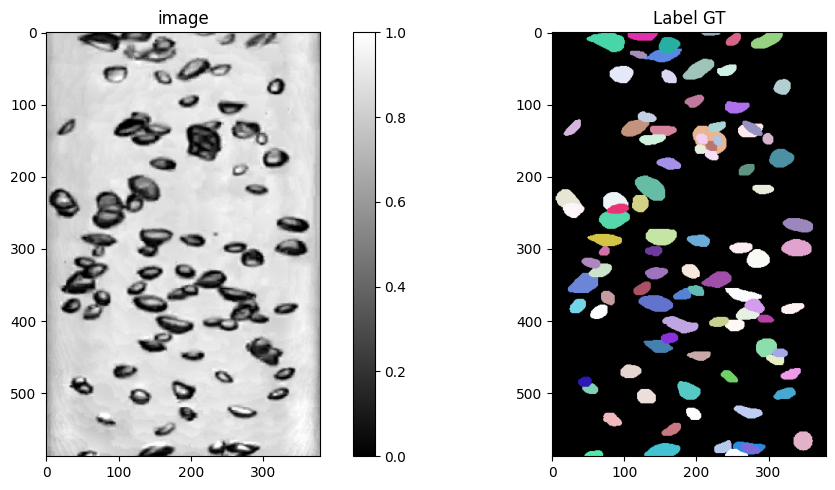


Prediction:


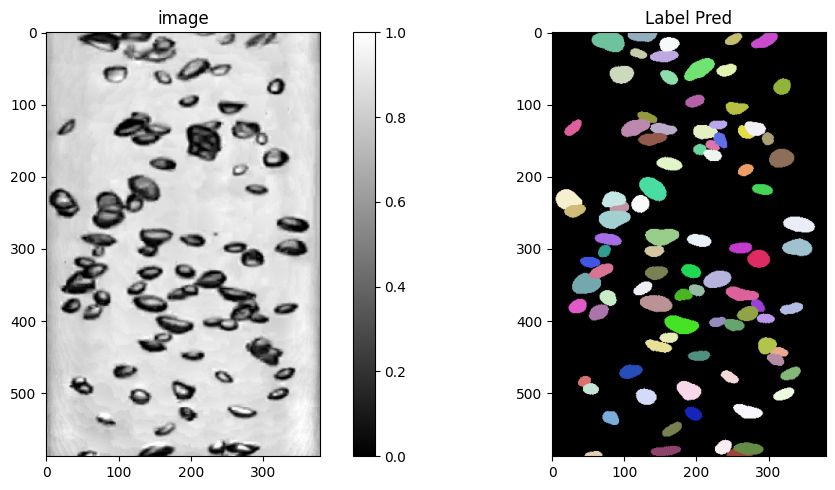

In [81]:
Y_val_pred = valPrediction(model)
plot_GT_Pred(Y_val_pred)

In [82]:
stats = matching_IoUs(Y_val = Y_val, Y_val_pred = Y_val_pred)

Computing matching stats: 100%|██████████| 9/9 [00:03<00:00,  2.99it/s]


KẾT QUẢ ĐÁNH GIÁ

IoU threshold τ = 0.1:
  - Precision: 0.9800
  - Recall:    0.9436
  - F1:        0.9615
  - TP: 2645, FP: 54, FN: 158

IoU threshold τ = 0.2:
  - Precision: 0.9796
  - Recall:    0.9433
  - F1:        0.9611
  - TP: 2644, FP: 55, FN: 159

IoU threshold τ = 0.3:
  - Precision: 0.9778
  - Recall:    0.9415
  - F1:        0.9593
  - TP: 2639, FP: 60, FN: 164

IoU threshold τ = 0.4:
  - Precision: 0.9726
  - Recall:    0.9365
  - F1:        0.9542
  - TP: 2625, FP: 74, FN: 178

IoU threshold τ = 0.5:
  - Precision: 0.9552
  - Recall:    0.9197
  - F1:        0.9371
  - TP: 2578, FP: 121, FN: 225

IoU threshold τ = 0.6:
  - Precision: 0.9215
  - Recall:    0.8873
  - F1:        0.9040
  - TP: 2487, FP: 212, FN: 316

IoU threshold τ = 0.7:
  - Precision: 0.8622
  - Recall:    0.8302
  - F1:        0.8459
  - TP: 2327, FP: 372, FN: 476

IoU threshold τ = 0.8:
  - Precision: 0.6643
  - Recall:    0.6397
  - F1:        0.6518
  - TP: 1793, FP: 906, FN: 1010

IoU threshold τ 

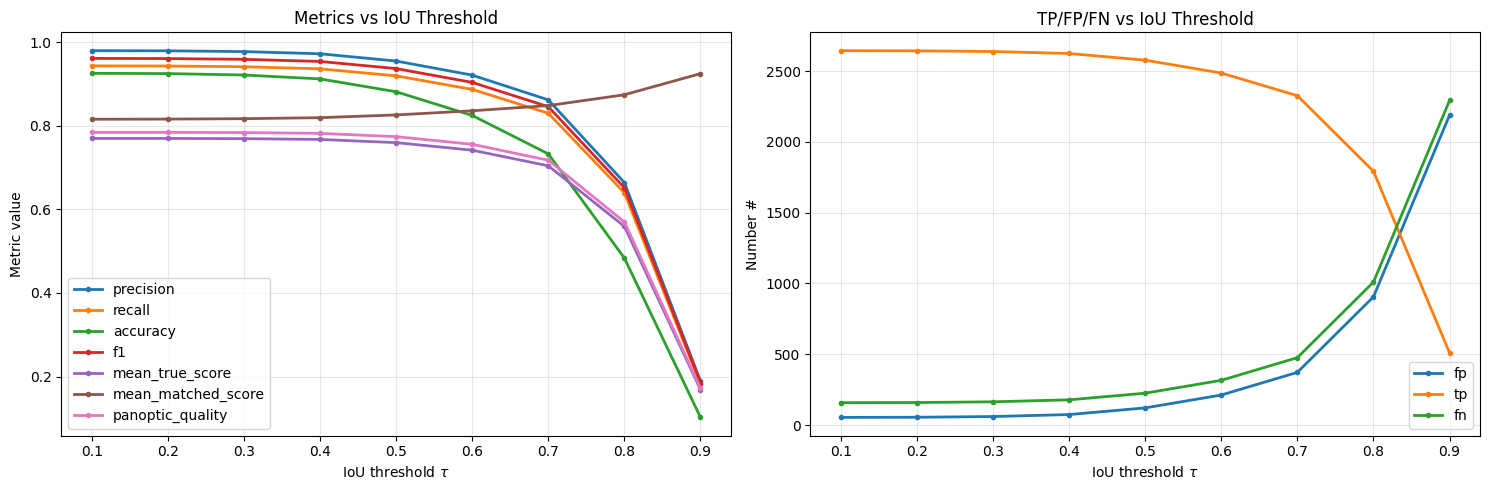


✓ Đã lưu biểu đồ vào /kaggle/working/models/200_flat_origin_val_loss_false/metrics


In [83]:
plot_results_details(stats = stats,model_name = model_name)

In [84]:
# 1. Xóa các biến to
if 'model' in locals():
    del model
if 'history' in locals():
    del history
if 'Y_val_pred' in locals():
    del Y_val_pred
if 'cfg' in locals():
    del cfg
if 'LOG_DIR' in locals():
    del LOG_DIR   
if 'model_name' in locals():
    del model_name  

# 2. Dọn rác
import gc
gc.collect()

# 3. (Nếu dùng GPU) Dọn sạch bộ nhớ GPU cho TensorFlow/Keras
import tensorflow.keras.backend as K
K.clear_session()

In [85]:
!zip -r models.zip /kaggle/working/models

  adding: kaggle/working/models/ (stored 0%)
  adding: kaggle/working/models/200_flat_origin_dist_dist_iou_metric_true/ (stored 0%)
  adding: kaggle/working/models/200_flat_origin_dist_dist_iou_metric_true/config.json (deflated 57%)
  adding: kaggle/working/models/200_flat_origin_dist_dist_iou_metric_true/metrics/ (stored 0%)
  adding: kaggle/working/models/200_flat_origin_dist_dist_iou_metric_true/metrics/training_history.png (deflated 9%)
  adding: kaggle/working/models/200_flat_origin_dist_dist_iou_metric_true/metrics/matching_tau_curve.png (deflated 6%)
  adding: kaggle/working/models/200_flat_origin_dist_dist_iou_metric_true/weights_best.h5 (deflated 8%)
  adding: kaggle/working/models/200_flat_origin_dist_dist_iou_metric_true/logs/ (stored 0%)
  adding: kaggle/working/models/200_flat_origin_dist_dist_iou_metric_true/logs/training_history.png (deflated 9%)
  adding: kaggle/working/models/200_flat_origin_dist_dist_iou_metric_true/logs/history_final.csv (deflated 57%)
  adding: kagg